# Series Temporales

El objetivo de esta práctica es la implementación de arquitecturas de Deep Learning orientadas al análisis y predicción de Series Temporales. Para el desarrollo de la práctica se utilizará el dataset [Weather Long-term Time
Series Forecasting](https://www.kaggle.com/datasets/alistairking/weather-long-term-time-series-forecasting/). En concreto, se desea predecir la temperatura para un horizonte igual a 1, es decir, la temperatura en el siguiente instante temporal; así como también realizar una comparativa entre una modelo baseline y, al menos, una propuesta utilizando los conocimiento obtenidos a lo largo de la asignatura.

## 0. Preparar ambiente

In [1]:
# Instalamos pytorch-lightning y ray
%%capture
!pip install pytorch-lightning
!pip install ray[tune,air]

In [2]:
import torch
import torch.nn as nn
from torchmetrics import MeanSquaredError, MeanAbsoluteError

# Pytorch Lightning
from pytorch_lightning import seed_everything, LightningDataModule, LightningModule, Trainer, Callback
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Fine-tuning
from ray import tune
from ray.air import session
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from ray.tune.integration.pytorch_lightning import TuneReportCheckpointCallback

# Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Basics
import numpy as np
import pandas as pd
import os
import re

# Graficas
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer dataset directo de kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Seteamos el SEED
SEED = 42
seed_everything(seed=SEED, workers=True)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [3]:
# Vinculamos Drive
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega'

Mounted at /content/drive


### 0.1 Utils

In [4]:
class TemperaturePredictor(LightningModule):
    def __init__(self, model, learning_rate=1e-3, optimizer=torch.optim.Adam):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate

        self.model = model
        self.optimizer = optimizer

        self.criterion = nn.L1Loss()
        self.rmse = MeanSquaredError(squared=False)

    def forward(self, x):
        return self.model(x)

    def process_step(self, batch, split='train'):
        inputs, targets = batch
        output = self(inputs)

        preds = output.view(-1)
        targets = targets.view(-1)

        loss = self.criterion(preds, targets)
        self.log_dict(
            {
                f'{split}_loss': loss,
                f'{split}_rmse': self.rmse(preds, targets),
            },
            on_epoch=True, on_step=False, prog_bar=True)

        return loss

    def training_step(self, batch, batch_idx):
        return self.process_step(batch, 'train')

    def validation_step(self, batch, batch_idx):
        return self.process_step(batch, 'val')

    def test_step(self, batch, batch_idx):
        return self.process_step(batch, 'test')

    def configure_optimizers(self):
        return self.optimizer(self.parameters(), lr=self.learning_rate)

class PlotCallback(Callback):
    def __init__(self):
        super().__init__()
        # Preparamos historial
        self.train_losses = []
        self.val_losses = []
        self.train_rmse = []
        self.val_rmse = []

    def on_train_epoch_end(self, trainer, pl_module):
        # Guardamos los valores por epoca
        self.train_losses.append(trainer.callback_metrics["train_loss"].item())
        self.train_rmse.append(trainer.callback_metrics["train_rmse"].item())
        self.val_losses.append(trainer.callback_metrics["val_loss"].item())
        self.val_rmse.append(trainer.callback_metrics["val_rmse"].item())

    def on_fit_end(self, trainer, pl_module):
        # Graficamos el historico del Loss y RMSE
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        axes[0].plot(self.train_losses, label='Training')
        axes[0].plot(self.val_losses, label='Validation')
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Loss')
        axes[0].legend()

        axes[1].plot(self.train_rmse, label='Training')
        axes[1].plot(self.val_rmse, label='Validation')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('RMSE')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

class ForecastingCallback(Callback):
    def __init__(self):
        super().__init__()
        # Inicializamos las predicciones
        self.predictions = []

    def on_test_batch_end(self, trainer, pl_module, outputs, batch, batch_idx, dataloader_idx=0):
        # Calculamos la predicción
        X, _ = batch
        prediction = pl_module(X.to(pl_module.device))
        self.predictions.extend(prediction.cpu().detach().numpy())

    def on_test_end(self, trainer, pl_module):
        predictions = np.array(self.predictions).reshape(-1, 1)

        # Invertimos la transformación de los datos
        datamodule = trainer.datamodule
        predictions = datamodule.target_scaler.inverse_transform(predictions).tolist()

        # Graficamos todos los datos y la predicción
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(datamodule.data['date'][-len(predictions)-1_000:], datamodule.data['T'][-len(predictions)-1_000:], label='Real')
        ax.plot(datamodule.data['date'][-len(predictions):], predictions, color='red', label='Prediction')
        ax.legend()
        ax.set_title('Temperature')
        ax.set_xlabel('Date')
        ax.set_ylabel('Temperature (ºC)')

        plt.tight_layout()
        plt.show()

class BaseRNNModel(nn.Module):
    def __init__(self, input_size, h=1, hidden_size=64, num_layers=2, dropout=0.0, pooling='last', model='rnn'):
        super().__init__()
        # Posibles modelos
        models = { 'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU }

        # Inicializamos
        self.pooling = pooling
        self.rnn = models[model](input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.out = nn.Linear(hidden_size, h)

    def forward(self, x):
        outputs, *_ = self.rnn(x)
        if self.pooling == 'last':
            x = outputs[:, -1, :]
        elif self.pooling == 'mean':
            x = torch.mean(outputs, dim=1)
        else:
            x = torch.amax(outputs, dim=1)
        x = self.out(x)
        return x

def inference(model, data_module, device, forescasting=False):
    model.eval()
    data_module.setup('test')

    # Inicializamos
    model = model.to(device)
    target_scaler = data_module.target_scaler
    predictions = []
    criterion = nn.L1Loss()
    rmse = MeanSquaredError(squared=False)
    test_loss = 0
    test_rmse = 0
    test_dataloader = data_module.test_dataloader()

    with torch.no_grad():
        for inputs, target in test_dataloader:
            # Movemos al device del model
            inputs = inputs.to(device)
            target = target.to(device)

            # Predicciones
            output = model(inputs)

            # Reescalamos
            target = target_scaler.inverse_transform(target.cpu().numpy())
            pred = target_scaler.inverse_transform(output.cpu().numpy())

            # Convertimos a tensor
            target = torch.tensor(target)
            output = torch.tensor(pred)

            # Calculamos MAE y RMSE en base a los datos reales
            loss = criterion(output, target)
            test_loss += loss.item()
            rmse_step = rmse(output, target)
            test_rmse += rmse_step.item()

            predictions.append(pred)


    predictions = np.concatenate(predictions, axis=0)
    test_loss /= len(test_dataloader)
    test_rmse /= len(test_dataloader)

    if forescasting: plot_forescasting(predictions, data_module)

    return { 'test_loss': test_loss, 'test_rmse': test_rmse }

def plot_forescasting(predictions, data_module):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(data_module.data['date'][-len(predictions)-1_000:], data_module.data['T'][-len(predictions)-1_000:], label='Real')
    ax.plot(data_module.data['date'][-len(predictions):], predictions, color='red', label='Prediction')
    ax.legend()
    ax.set_title('Temperature')
    ax.set_xlabel('Date')
    ax.set_ylabel('Temperature (ºC)')

    plt.tight_layout()
    plt.show()


## 1. Exploración y preparación de los Datos

### 1.1 Cargar e inspeccionar dataset

In [5]:
# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  'alistairking/weather-long-term-time-series-forecasting',
  'cleaned_weather.csv',
  pandas_kwargs={'parse_dates': ['date']}
)

df.head()

100%|██████████| 6.55M/6.55M [00:00<00:00, 7.78MB/s]


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


In [6]:
# Mostrar información básica
print(f'Forma del Dataset: {df.shape}')

print("\nEstadísticas Básicas:")
display(df.describe(include='all'))

print("\nTipos de Datos:")
display(df.info())

Forma del Dataset: (52696, 21)

Estadísticas Básicas:


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
count,52696,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,...,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000,52696.000000
mean,2020-07-02 00:11:52.198269440,989.989233,10.818241,284.796938,5.409105,72.487133,14.487046,9.676828,4.810131,6.111159,...,1210.882855,1.995935,3.632807,176.850276,0.011773,25.907469,131.331822,259.863438,308.601939,21.515206
min,2020-01-01 00:10:00,955.580000,-6.440000,266.190000,-13.810000,21.160000,3.770000,2.090000,0.000000,1.300000,...,1107.380000,-9999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9999.000000,6.900000
25%,2020-04-01 11:47:30,984.800000,4.590000,278.550000,0.777500,58.820000,8.480000,6.460000,1.170000,4.070000,...,1183.900000,1.000000,1.770000,141.100000,0.000000,0.000000,0.000000,0.000000,0.000000,15.240000
50%,2020-07-02 00:45:00,990.920000,10.230000,284.320000,5.260000,75.400000,12.480000,8.890000,2.740000,5.610000,...,1210.800000,1.770000,3.000000,195.500000,0.000000,0.000000,2.820000,9.670000,13.120000,20.440000
75%,2020-10-01 12:22:30,995.930000,16.180000,290.260000,9.700000,87.900000,18.420000,12.050000,6.440000,7.620000,...,1236.550000,2.920000,4.850000,226.700000,0.000000,0.000000,182.900000,366.437500,434.260000,26.822500
max,2021-01-01 00:00:00,1020.070000,34.800000,309.130000,20.500000,100.000000,55.670000,24.160000,42.100000,15.400000,...,1318.520000,13.770000,22.900000,360.000000,11.200000,600.000000,1115.290000,2131.760000,2498.940000,49.090000
std,NaN,9.207149,7.468671,7.616995,5.956722,19.230260,7.632960,4.023504,5.539320,2.561536,...,36.430222,43.596931,2.462467,81.194840,0.123289,111.503420,215.735116,422.786515,569.956762,7.790620



Tipos de Datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      52696 non-null  datetime64[ns]
 1   p         52696 non-null  float64       
 2   T         52696 non-null  float64       
 3   Tpot      52696 non-null  float64       
 4   Tdew      52696 non-null  float64       
 5   rh        52696 non-null  float64       
 6   VPmax     52696 non-null  float64       
 7   VPact     52696 non-null  float64       
 8   VPdef     52696 non-null  float64       
 9   sh        52696 non-null  float64       
 10  H2OC      52696 non-null  float64       
 11  rho       52696 non-null  float64       
 12  wv        52696 non-null  float64       
 13  max. wv   52696 non-null  float64       
 14  wd        52696 non-null  float64       
 15  rain      52696 non-null  float64       
 16  raining   52696 non-null  float64       


None

In [7]:
# Comprobar valores ausentes
print("Recuento de Valores Ausentes:")
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage': missing_percentage
})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))

Recuento de Valores Ausentes:


,Missing Count,Percentage


No hay valores faltantes en ninguna feature. Todas las features son númericas excepto la variable temporal. Nuestra variable objetivo es la temperatura T

### 1.2 Análisis de variable objetivo

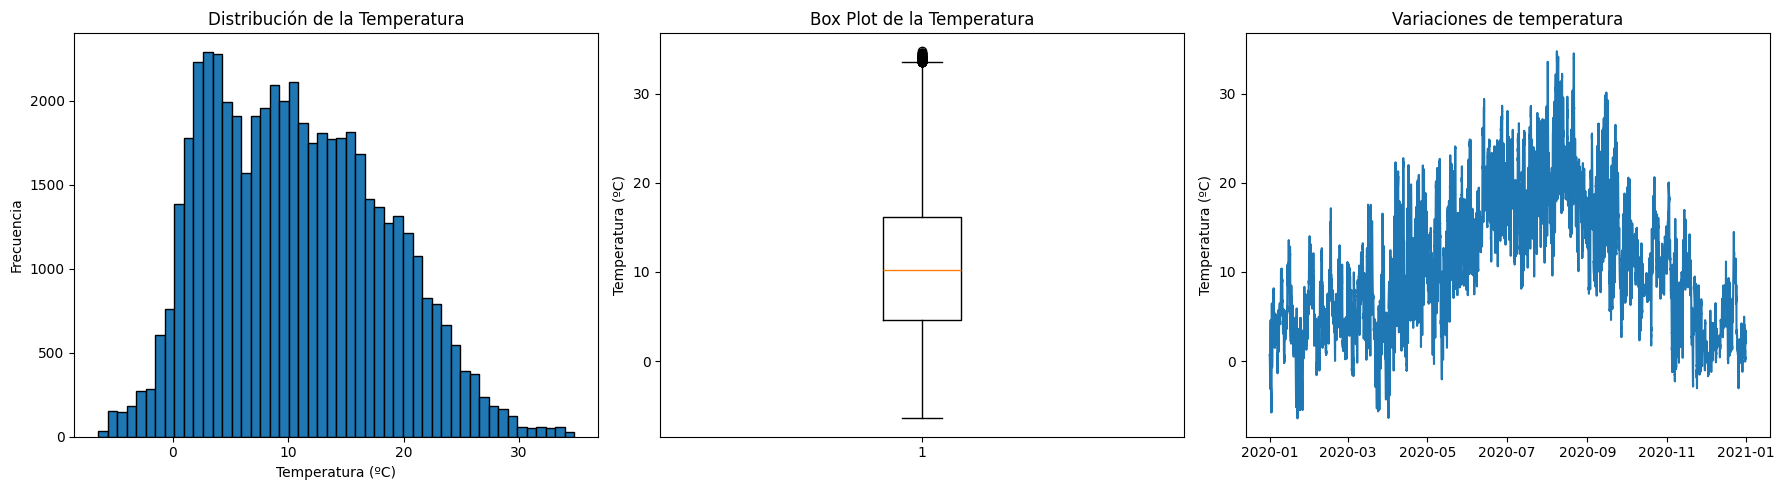

In [8]:
# Seleccionamos el target
target = df['T']

# Crear gráficos de análisis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico de distribución
axes[0].hist(target, bins=50, edgecolor='black')
axes[0].set_xlabel('Temperatura (ºC)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de la Temperatura')

# Box plot
axes[1].boxplot(target)
axes[1].set_ylabel('Temperatura (ºC)')
axes[1].set_title('Box Plot de la Temperatura')

# Lineplot
axes[2].plot(df.date, target)
axes[2].set_ylabel('Temperatura (ºC)')
axes[2].set_title('Variaciones de temperatura')

plt.tight_layout()
plt.show()

No parece haber datos u outliers extraordinarios, los valores tienen sentido. Se aprecian muchas variaciones en la temperatura a lo largo del tiempo, es muy probable que el marco temporal entre cada medición sea relativamente pequeño

### 1.3 Análisis de variable temporal

In [9]:
# Marco temporal completo
print(f'Fecha mínima: {df.date.min()}')
print(f'Fecha máxima: {df.date.max()}')
print(f'Duración: {df.date.max() - df.date.min()}')

# Frequencia de las mediciones
display(df.date.diff().value_counts())

Fecha mínima: 2020-01-01 00:10:00
Fecha máxima: 2021-01-01 00:00:00
Duración: 365 days 23:50:00


,count
date,
0 days 00:10:00,52693
0 days 00:00:00,1
0 days 01:40:00,1


El dataset cubre mediciones a lo largo de un año con una frecuencia de 10 minutos. Sin embargo, hay dos casos atípicos, una diferencia de 0 min y otro de 1 hora con 40 minutos. Esto tiene sentido ya que, de tener todos los datos:

Número de registros = 366 días x 24 h/día x 6 registros/h = 52704 registros != 52696

In [10]:
# Fechas con mayor y menor diferencia
biggest_diff_idx = df.date.diff().idxmax()
smallest_diff_idx = df.date.diff().idxmin()

# Mayor diferencia
print('Mayor diferencia entre registros')
display(df.loc[biggest_diff_idx - 2:biggest_diff_idx + 2])

# Menor diferencia
print('\nMenor diferencia entre registros')
display(df.loc[smallest_diff_idx - 2:smallest_diff_idx + 2])

print('\nRegistro duplicados')
display(df[df.duplicated()])

Mayor diferencia entre registros


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
21512,2020-05-29 09:20:00,1002.51,17.38,290.32,8.04,54.15,19.88,10.76,9.11,6.71,...,1197.18,2.59,5.17,48.04,0.0,0.0,815.69,1554.05,1781.85,23.04
21513,2020-05-29 09:30:00,1002.51,17.17,290.11,7.79,53.97,19.62,10.59,9.03,6.60,...,1198.13,3.28,6.21,41.15,0.0,0.0,565.59,1079.34,1710.42,22.19
21514,2020-05-29 11:10:00,1002.14,15.28,288.25,4.84,49.63,17.39,8.63,8.76,5.37,...,1206.42,4.11,6.91,55.37,0.0,0.0,926.91,1781.38,2203.91,18.66
21515,2020-05-29 11:20:00,1002.06,15.31,288.29,4.51,48.42,17.42,8.44,8.99,5.25,...,1206.30,4.94,7.53,39.84,0.0,0.0,698.89,1371.24,2162.33,19.41
21516,2020-05-29 11:30:00,1002.01,15.12,288.10,4.03,47.38,17.21,8.15,9.06,5.08,...,1207.16,3.79,5.85,59.46,0.0,0.0,728.47,1421.16,2057.16,20.40



Menor diferencia entre registros


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
19042,2020-05-12 05:50:00,991.40,-1.53,272.29,-2.02,96.5,5.46,5.27,0.19,3.31,...,1268.97,0.72,1.44,197.0,0.0,0.0,69.01,145.17,179.34,10.10
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,-2.09,96.2,5.44,5.24,0.21,3.29,...,1269.29,1.04,1.68,215.4,0.0,0.0,84.91,176.64,199.61,10.19
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,-2.09,96.2,5.44,5.24,0.21,3.29,...,1269.29,1.04,1.68,215.4,0.0,0.0,84.91,176.64,199.61,10.19
19045,2020-05-12 06:10:00,991.64,-1.46,272.35,-1.95,96.4,5.49,5.29,0.20,3.33,...,1268.90,1.06,1.52,226.7,0.0,0.0,108.65,218.73,260.23,10.32
19046,2020-05-12 06:20:00,991.72,-1.24,272.56,-1.73,96.4,5.58,5.38,0.20,3.38,...,1267.93,1.11,1.58,213.3,0.0,0.0,145.88,281.85,390.35,10.48



Registro duplicados


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,-2.09,96.2,5.44,5.24,0.21,3.29,...,1269.29,1.04,1.68,215.4,0.0,0.0,84.91,176.64,199.61,10.19


Faltan 9 registros del 29 de mayo entre las 9:30 am y 11:10 am. Por otro lado, hay un dato duplicado, tenemos dos registros para el 12 de mayo a las 6:00 am. Debemos eliminar el dato duplicado y aplicar interpolación para llenar los datos faltantes

### 1.4 Features númericas

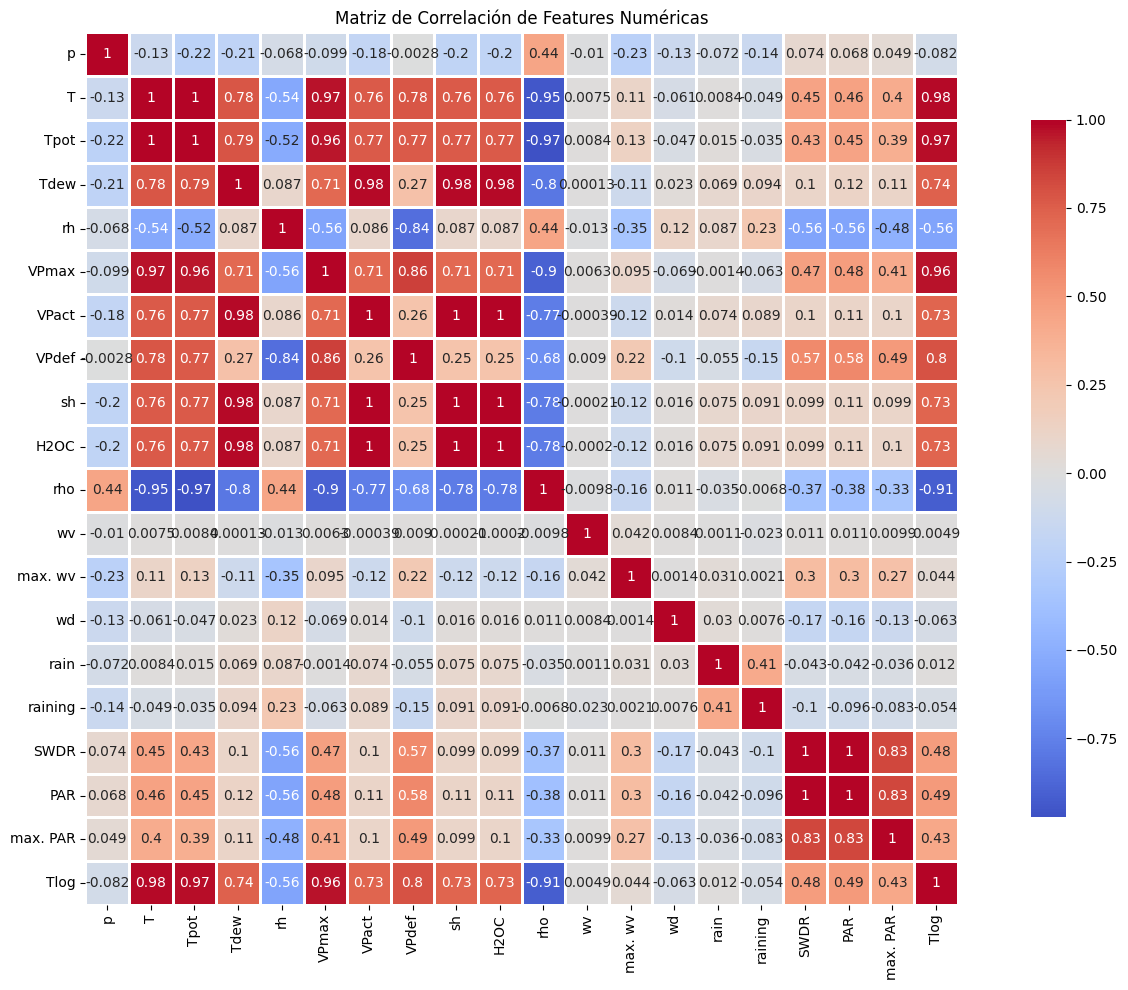

In [11]:
# Extraemos las columnas númericas
numerical_features = df.select_dtypes(include='number').columns.tolist()

# Matriz de correlación
plt.figure(figsize=(15, 10))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Features Numéricas')
plt.tight_layout()
plt.show()

In [12]:
# Identificar características altamente correlacionadas
threshold = 0.9
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    n_ocurrences = {}
    print(f'\nSe encontraron {len(high_corr_pairs)} pares de características altamente correlacionadas (|r| > {threshold}):')
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")

        n_ocurrences[feat1] = n_ocurrences.get(feat1, 0) + 1
        n_ocurrences[feat2] = n_ocurrences.get(feat2, 0) + 1

    print(f'\nFeatures con más correlaciones: {sorted(n_ocurrences.items(), key=lambda x: x[1], reverse=True)}')


Se encontraron 17 pares de características altamente correlacionadas (|r| > 0.9):
  sh <-> H2OC: 1.000
  VPact <-> H2OC: 1.000
  VPact <-> sh: 1.000
  SWDR <-> PAR: 0.999
  T <-> Tpot: 0.995
  T <-> Tlog: 0.982
  Tdew <-> VPact: 0.977
  Tdew <-> H2OC: 0.977
  Tdew <-> sh: 0.977
  Tpot <-> rho: -0.973
  Tpot <-> Tlog: 0.973
  T <-> VPmax: 0.968
  VPmax <-> Tlog: 0.963
  Tpot <-> VPmax: 0.961
  T <-> rho: -0.947
  rho <-> Tlog: -0.913
  VPmax <-> rho: -0.900

Features con más correlaciones: [('T', 4), ('Tpot', 4), ('Tlog', 4), ('rho', 4), ('VPmax', 4), ('sh', 3), ('H2OC', 3), ('VPact', 3), ('Tdew', 3), ('SWDR', 1), ('PAR', 1)]


Existe una gran correlación entre muchos de los datos. Entre ellos podemos destacar:
*  `T`, `Tpot`, `Tlog`, `VPmax`, y `rho` está altamente correlacionadas entre ellas
*  `sh`, `H2OC`, `VPact`, y `Tdew` también se encuentran muy correlacionadas

Para solucionar los problemas inherentes y simplificar el entrenamiento podemos eliminar la correlación y reducir la dimensionalidad:

*   Implementar herramientas de Feature Selection
*   Utilizar PCA para descomposición

Ahora evaluemos la distribución de las feature númericas:

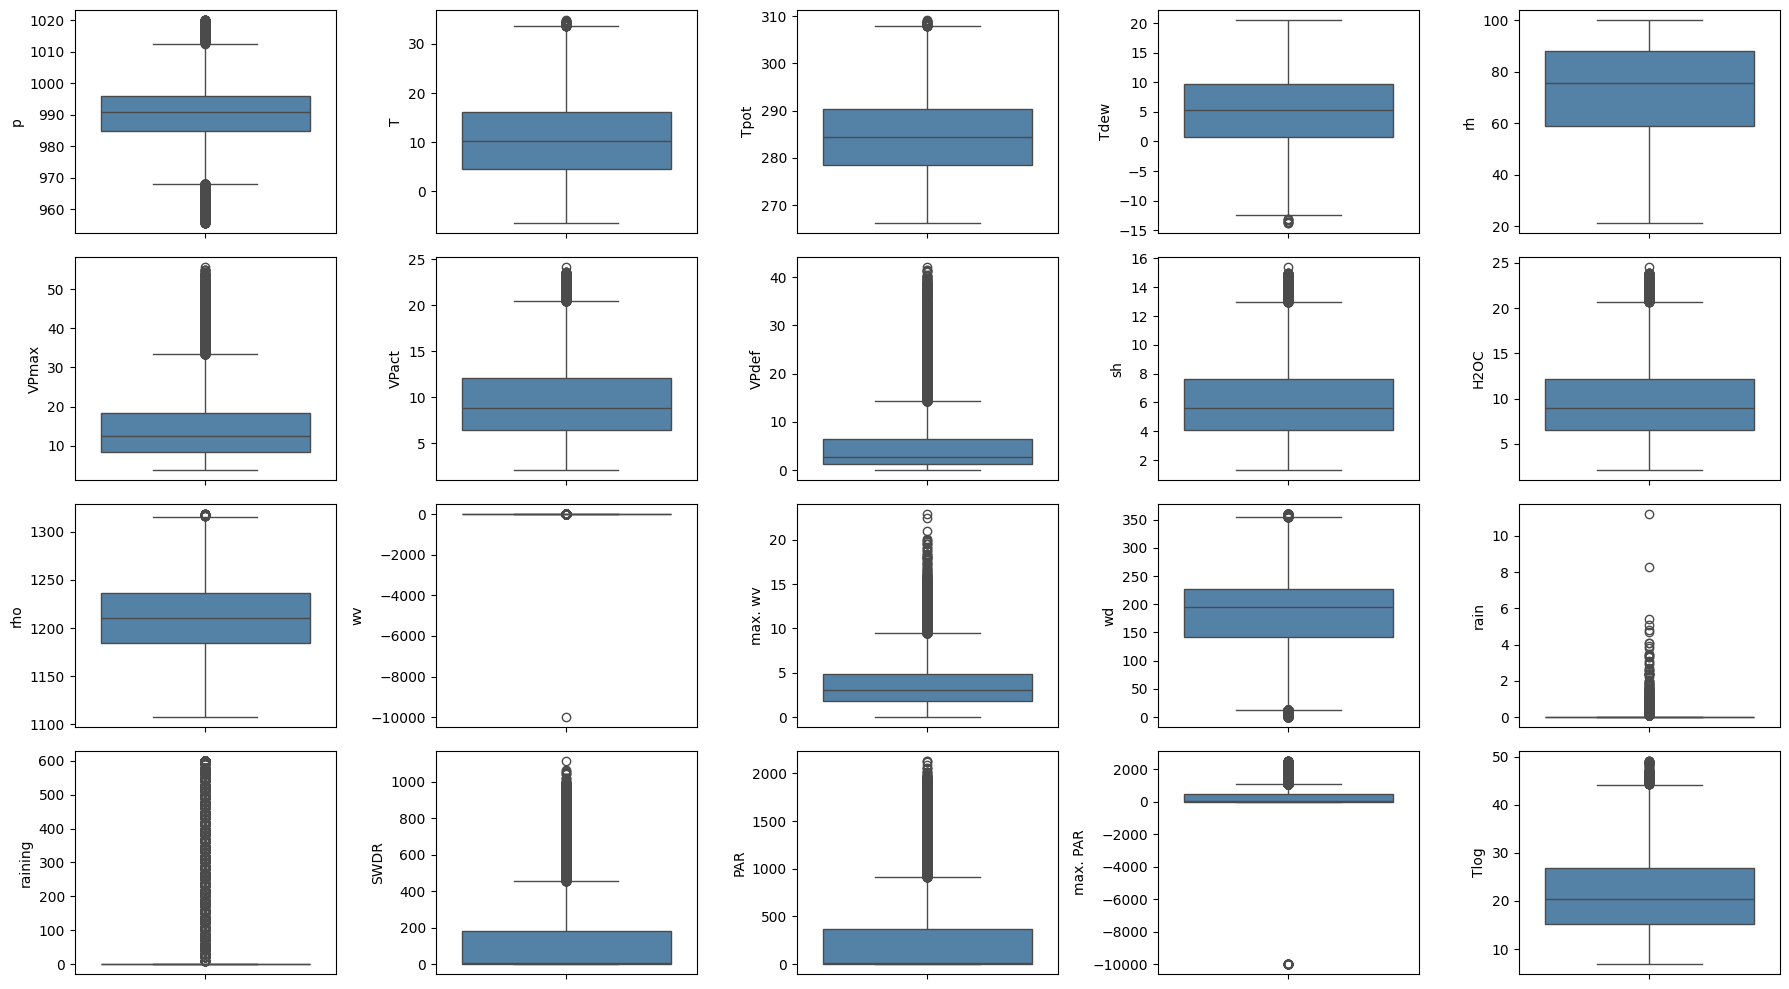

In [13]:
# Preparamos gráficas
fig, axes = plt.subplots(4, 5, figsize=(18, 10))

axes = axes.flatten()

# Hacemos un boxplot para cada feature
for i, col in enumerate(numerical_features):
    sns.boxplot(df, y=col, ax=axes[i], color='steelblue')

plt.tight_layout()
plt.show()

Todas las features tienen outliers, sin embargo, no los podemos eliminar porque necesitamos mantener la tendencia temporal. Implementaremos estandarización u otras conversiones más robustas

### 1.5 Dataset y DataModule

In [14]:
class TemperatureDataset(torch.utils.data.Dataset):
    def __init__(self, df, w=4, h=1):
        self.features = df.drop(columns=['date', 'T']).values
        self.target = df['T'].values
        self.w = w
        self.h = h

    def __len__(self):
        return len(self.features) - (self.w + self.h) + 1

    def __getitem__(self, idx):
        features = self.features[idx:idx + self.w]
        target = self.target[idx + self.w: idx + self.w + self.h]
        return features, target

In [15]:
class TemperatureDataModule(LightningDataModule):
    def __init__(self, df, w=4, h=1, batch_size=16, val_size=0.1, test_size=0.2, reduction_strategy=None):
        super().__init__()
        # Inicalizamos los atributos de la clase
        self.data = df
        self.w = w
        self.h = h
        self.batch_size = batch_size

        # Preprocesamos el dataset
        self.data.drop_duplicates(inplace=True) # Quitamos duplicados
        self.impute_missing_values() # Imputamos valores faltantes
        self.train_df, self.val_df, self.test_df = self.sequential_train_val_test_split(val_size=val_size, test_size=test_size) # Split
        self.feature_scaler, self.target_scaler = self.normalize() # Normalizamos
        self.reductor = self.feature_reduction(reduction_strategy) # Reducimos dimensionalidad

    def setup(self, stage=None):
        if stage == 'fit':
            self.train_dataset = TemperatureDataset(self.train_df, w=self.w, h=self.h)
            self.val_dataset = TemperatureDataset(self.val_df, w=self.w, h=self.h)
        elif stage == 'test':
            self.test_dataset = TemperatureDataset(self.test_df, w=self.w, h=self.h)

    def impute_missing_values(self):
        # Buscamos fechas faltante
        freq = '10min' # Frecuencia de 10 minutors
        date_range = pd.date_range(start=self.data.date.min(), end=self.data.date.max(), freq=freq)
        missing_dates = date_range[~date_range.isin(self.data.date)]

        # Agregamos las fechas
        missing_df = pd.DataFrame({ 'date': missing_dates })
        self.data = pd.concat([self.data, pd.DataFrame({ 'date': missing_dates })]).reset_index(drop=True)

        # Interpolamos los datos faltantes
        self.data.set_index('date', inplace=True)
        self.data.interpolate(method='time', inplace=True)
        self.data.reset_index(inplace=True)

    def sequential_train_val_test_split(self, val_size, test_size):
        self.data.sort_values('date', inplace=True)

        # Calculamos los ínidices para hacer los splits
        n = len(self.data)
        train_end = int((1 - val_size - test_size) * n)
        val_end = int((1 - test_size) * n)

        # Hacemos el split
        train = self.data.iloc[:train_end].copy()
        val = self.data.iloc[train_end:val_end].copy()
        test = self.data.iloc[val_end:].copy()

        return train, val, test

    def normalize(self):
        # Inicializamos el scaler
        feature_scaler = StandardScaler()
        target_scaler = StandardScaler()

        # Seleccionamos las features a transformar
        numerical_features = self.data.select_dtypes(include='number').columns.tolist()
        numerical_features.remove('T')
        target = ['T']

        # Ajustamos con train y transformamos todo
        self.train_df.loc[:, numerical_features] = feature_scaler.fit_transform(self.train_df[numerical_features])
        self.train_df.loc[:, target] = target_scaler.fit_transform(self.train_df[target])

        self.val_df.loc[:, numerical_features] = feature_scaler.transform(self.val_df[numerical_features])
        self.val_df.loc[:, target] = target_scaler.transform(self.val_df[target])
        self.test_df.loc[:, numerical_features] = feature_scaler.transform(self.test_df[numerical_features])
        self.test_df.loc[:, target] = target_scaler.transform(self.test_df[target])
        return feature_scaler, target_scaler

    def feature_reduction(self, strategy, k=12):
        # Seleccionamos las features que pueden ser modificadas
        features_to_transform = self.data.select_dtypes(include='number').columns.tolist()
        features_to_transform.remove('T')

        if strategy == 'pca':
            # Inicializamos PCA
            pca = PCA(n_components=k, random_state=SEED)

            # Ajustamos con train y transformamos todo
            pca_train = pca.fit_transform(self.train_df[features_to_transform])
            pca_val = pca.transform(self.val_df[features_to_transform])
            pca_test = pca.transform(self.test_df[features_to_transform])

            # Ajustamos datos
            for i in range(pca_train.shape[1]):
                self.train_df[f'pca_{i+1}'] = pca_train[:, i]
                self.val_df[f'pca_{i+1}'] = pca_val[:, i]
                self.test_df[f'pca_{i+1}'] = pca_test[:, i]

            # Eliminamos datos originales
            self.train_df.drop(columns=features_to_transform, inplace=True)
            self.val_df.drop(columns=features_to_transform, inplace=True)
            self.test_df.drop(columns=features_to_transform, inplace=True)

            return pca

        elif strategy == 'selection':
            # Inicializamos KBest
            k_best = SelectKBest(mutual_info_regression, k=k)

            # Ajustamos con train
            k_best.fit(self.train_df[features_to_transform], self.train_df['T'])

            # Features finales
            best_features = ['date', 'T'] + k_best.get_feature_names_out().tolist()

            # Filtramos
            self.train_df = self.train_df[best_features]
            self.val_df = self.val_df[best_features]
            self.test_df = self.test_df[best_features]

            return k_best

    def collate_fn(self, batch):
        features, targets = zip(*batch)

        features = np.stack(features, axis=0)
        targets = np.stack(targets, axis=0)

        features = torch.tensor(features, dtype=torch.float32)
        targets = torch.tensor(targets, dtype=torch.float32)
        return features, targets

    def train_dataloader(self):
        return torch.utils.data.DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, collate_fn=self.collate_fn)

    def val_dataloader(self):
        return torch.utils.data.DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, collate_fn=self.collate_fn)

    def test_dataloader(self):
        return torch.utils.data.DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, collate_fn=self.collate_fn)

In [16]:
# Preparamos varios DataModule que cumplen los criterios
# Simple DataModule (sin PCA o FeatureSelection)
print('SIMPLE DATAMODULE:')
simple_datamodule = TemperatureDataModule(df)
print(f' Shape: {simple_datamodule.train_df.shape}')
print(f' Features: {simple_datamodule.train_df.columns.tolist()}')
display(simple_datamodule.train_df.head())

# PCA DataModule
print('\nPCA DATAMODULE:')
pca_datamodule = TemperatureDataModule(df, reduction_strategy='pca')
print(f' Shape: {pca_datamodule.train_df.shape}')
print(f' Features: {pca_datamodule.train_df.columns.tolist()}')
display(pca_datamodule.train_df.head())

# FeatureSelection DataModule
print('\nFEATURE SELECTION DATAMODULE:')
selection_datamodule = TemperatureDataModule(df, reduction_strategy='selection')
print(f' Shape: {selection_datamodule.train_df.shape}')
print(f' Features: {selection_datamodule.train_df.columns.tolist()}')
display(selection_datamodule.train_df.head())

SIMPLE DATAMODULE:
 Shape: (36892, 21)
 Features: ['date', 'p', 'T', 'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh', 'H2OC', 'rho', 'wv', 'max. wv', 'wd', 'rain', 'raining', 'SWDR', 'PAR', 'max. PAR', 'Tlog']


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,2.113755,-1.460268,-1.608230,-1.052708,0.990598,-1.141403,-0.979187,-0.838788,-0.998563,...,1.940697,-0.017813,-0.832731,0.555976,-0.093499,-0.221035,-0.672981,-0.679715,-0.588564,-1.424240
1,2020-01-01 00:20:00,2.098694,-1.455085,-1.603177,-1.069726,0.942607,-1.138937,-0.990562,-0.828622,-1.009279,...,1.933078,-0.029138,-1.125484,0.354767,-0.093499,-0.221035,-0.672981,-0.679715,-0.588564,-1.416719
2,2020-01-01 00:30:00,2.087109,-1.457677,-1.604441,-1.075915,0.937274,-1.140170,-0.992837,-0.826928,-1.009279,...,1.932027,-0.025683,-0.878955,0.243239,-0.093499,-0.221035,-0.672981,-0.679715,-0.588564,-1.405437
3,2020-01-01 00:40:00,2.084792,-1.504322,-1.648655,-1.100668,1.001263,-1.161136,-1.008762,-0.843870,-1.023567,...,1.976163,-0.016085,-0.878955,0.350168,-0.093499,-0.221035,-0.672981,-0.679715,-0.588564,-1.392901
4,2020-01-01 00:50:00,2.081317,-1.509504,-1.653708,-1.079009,1.059920,-1.162369,-0.995112,-0.855730,-1.012851,...,1.979053,-0.027986,-0.909771,0.386960,-0.093499,-0.221035,-0.672981,-0.679715,-0.588564,-1.379112



PCA DATAMODULE:
 Shape: (36892, 14)
 Features: ['date', 'T', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10', 'pca_11', 'pca_12']


,date,T,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12
0,2020-01-01 00:10:00,-1.460268,-4.212791,0.255878,-1.159655,1.035518,0.178709,0.126850,1.122360,-0.264997,0.655611,0.028304,0.419253,-0.000355
1,2020-01-01 00:20:00,-1.455085,-4.212393,0.266552,-1.301690,1.168530,0.321387,0.152542,1.043202,-0.141184,0.438599,0.025168,0.387910,-0.026274
2,2020-01-01 00:30:00,-1.457677,-4.202161,0.193773,-1.206198,1.129530,0.301738,0.160570,0.869319,-0.239341,0.564370,0.035009,0.398152,-0.013376
3,2020-01-01 00:40:00,-1.504322,-4.270152,0.216846,-1.187563,1.114966,0.242959,0.152643,0.961165,-0.236987,0.574566,0.029367,0.433661,-0.000559
4,2020-01-01 00:50:00,-1.509504,-4.263402,0.269511,-1.193528,1.134189,0.214120,0.133922,0.997448,-0.230711,0.563165,0.025431,0.456991,0.021628



FEATURE SELECTION DATAMODULE:
 Shape: (36892, 14)
 Features: ['date', 'T', 'p', 'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh', 'H2OC', 'rho', 'max. PAR', 'Tlog']


,date,T,p,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,max. PAR,Tlog
0,2020-01-01 00:10:00,-1.460268,2.113755,-1.608230,-1.052708,0.990598,-1.141403,-0.979187,-0.838788,-0.998563,-0.999157,1.940697,-0.588564,-1.424240
1,2020-01-01 00:20:00,-1.455085,2.098694,-1.603177,-1.069726,0.942607,-1.138937,-0.990562,-0.828622,-1.009279,-1.008123,1.933078,-0.588564,-1.416719
2,2020-01-01 00:30:00,-1.457677,2.087109,-1.604441,-1.075915,0.937274,-1.140170,-0.992837,-0.826928,-1.009279,-1.012606,1.932027,-0.588564,-1.405437
3,2020-01-01 00:40:00,-1.504322,2.084792,-1.648655,-1.100668,1.001263,-1.161136,-1.008762,-0.843870,-1.023567,-1.026054,1.976163,-0.588564,-1.392901
4,2020-01-01 00:50:00,-1.509504,2.081317,-1.653708,-1.079009,1.059920,-1.162369,-0.995112,-0.855730,-1.012851,-1.014847,1.979053,-0.588564,-1.379112


## 2. Baseline

El Baseline debe cumplir con las siguientes condiciones:
*  100 neuronas y una única capa oculta.
*  Detención temprana del aprendizaje cuando el error de validación no decrece
durante 5 epochs (Early Stopping).
*  El modelo resultado es aquel con menor error de validación (Checkpointing).
*  Probar una razón de aprendizaje entre {0.1, 0.01, 0.001 y 0.0001}, eligiendo aquella que reporte mejor error sobre el conjunto de validación.
*  Optimizador SGD (Momento y otros hiper parámetros por defecto)
*  Tamaño de batch de 8.
*  Preprocesado mínimo de la entrada (normalización y aleatorización)

In [26]:
class BaselineModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=100, output_size=1):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

### 2.1 Entrenamiento

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Training con Learning Rate: 0.1


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/baseline exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaselineModel    │  7.8 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

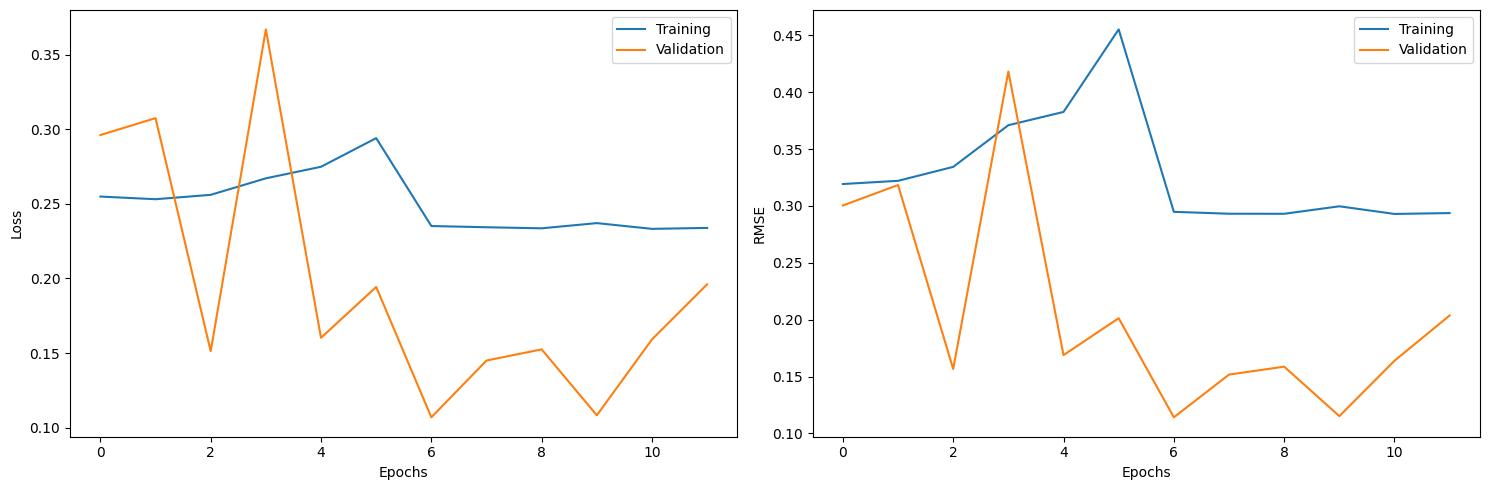

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.2839506268501282     │
│         test_rmse         │    0.2879749834537506     │
└───────────────────────────┴───────────────────────────┘

Training con Learning Rate: 0.01


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/baseline exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaselineModel    │  7.8 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

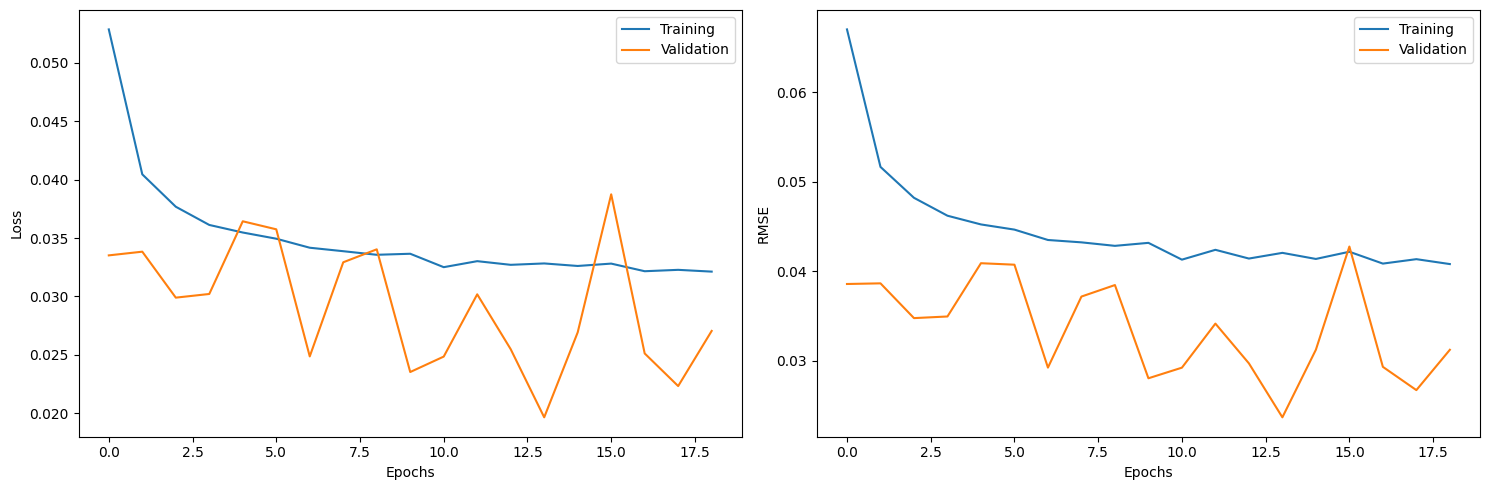

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.035769131034612656    │
│         test_rmse         │   0.038786910474300385    │
└───────────────────────────┴───────────────────────────┘

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Training con Learning Rate: 0.001


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/baseline exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaselineModel    │  7.8 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

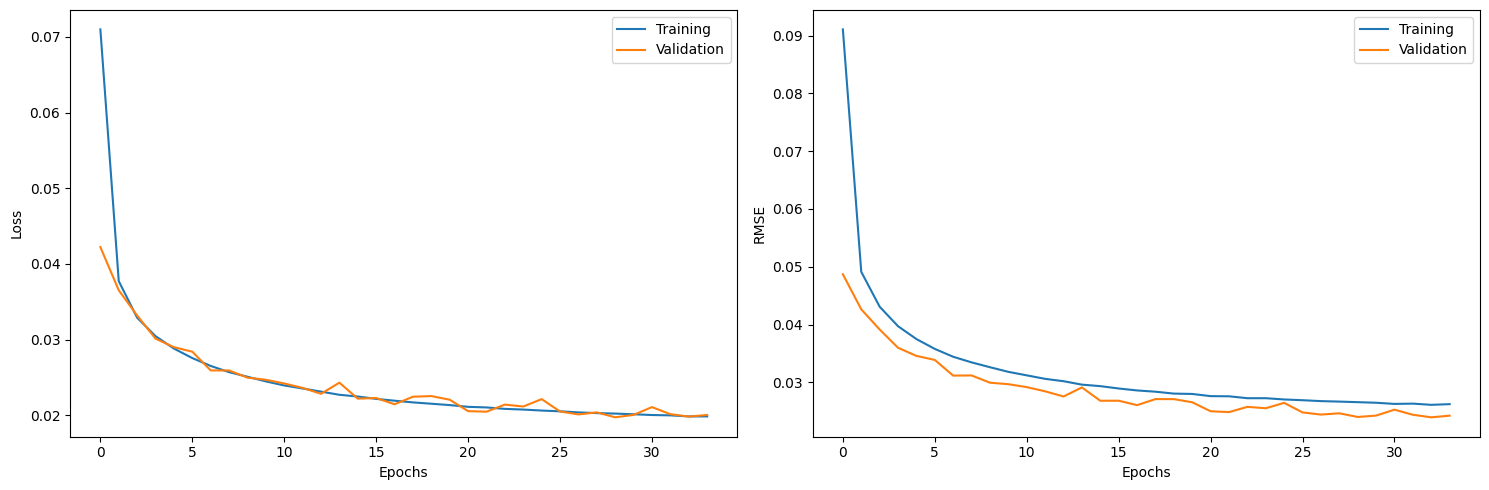

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.018640169873833656    │
│         test_rmse         │   0.021968580782413483    │
└───────────────────────────┴───────────────────────────┘

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Training con Learning Rate: 0.0001


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/baseline exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaselineModel    │  7.8 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


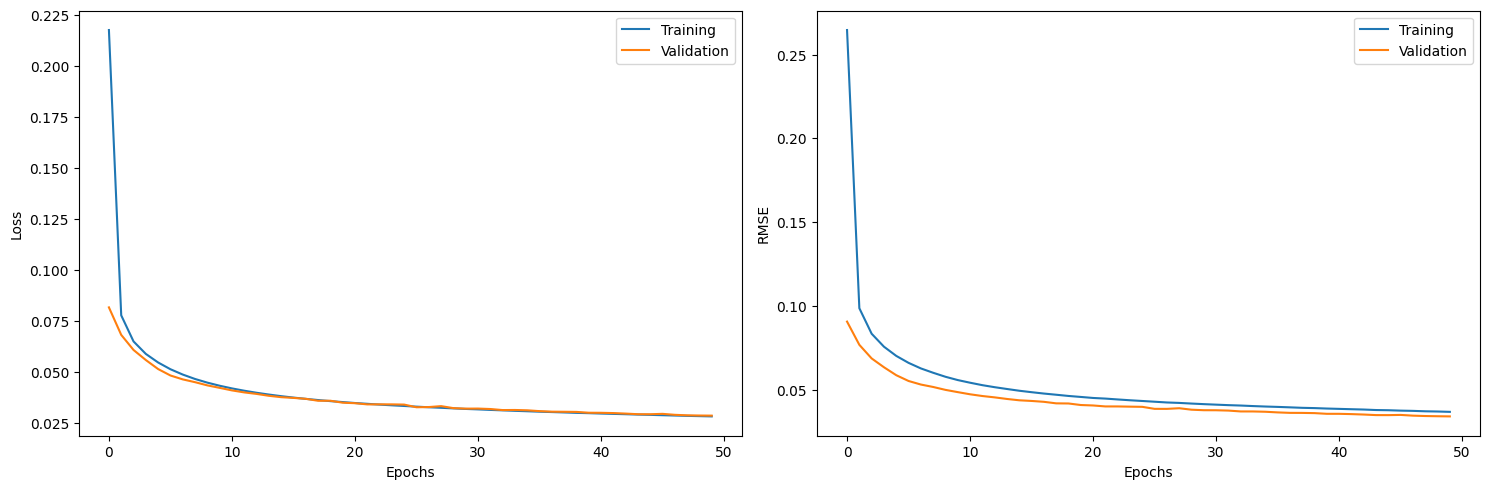

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.02428620494902134    │
│         test_rmse         │    0.02854141592979431    │
└───────────────────────────┴───────────────────────────┘

In [ ]:
results = []
# Preparamos DataModule
w = 4
data_module = TemperatureDataModule(df, batch_size=8, w=w)
data_module.setup('fit')
chk_path = f'{BASE_PATH}/baseline'

lrs = { '1e-1': 1e-1, '1e-2': 1e-2, '1e-3': 1e-3, '1e-4': 1e-4 }
for label, lr in lrs.items(): # Iteramos sobre los diferentes LR
    print(f'Training con Learning Rate: {lr}')

    # Preparamos Module
    input_size = data_module.train_dataset.features.shape[1] * w # Features * W
    model = BaselineModel(input_size=input_size)
    module = TemperaturePredictor(model, lr, optimizer=torch.optim.SGD)

    # Preparamos Trainer
    trainer = Trainer(
        deterministic=True,
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=5),
            ModelCheckpoint(monitor='val_loss', filename=f'best_model_{label}', dirpath=chk_path, enable_version_counter=False),
            PlotCallback()
        ],
        max_epochs=50
    )

    # Entrenamos y guardamos resultados
    trainer.fit(module, data_module)
    results.append(trainer.test(module, data_module)[0] | { 'lr': lr })

### 2.2 Análisis

Al ver las gráficas de pérdida y RMSE se puede observar que los modelos con un learning rate alto (0.1 y 0.01), no logran adaptarse a los datos correctamente y el entrenamiento se detiene muy rápido. Los resultados en el conjunto de validación oscilan considerablemente. Aún asi, no se obtienen malos resultados.

Los modelos con un learning de 0.001 y 0.0001 se adaptan mucho mejor al dataset. Se puede apreciar como la pérdida disminuye constantemente para entrenamiento y validación

Vamos a analizar los resultados con el conjunto de test en la última épooca:

In [ ]:
results_df = pd.DataFrame(results)
results_df.sort_values('test_loss', inplace=True)
results_df

,test_loss,test_rmse,lr
2,0.018640,0.021969,0.0010
3,0.024286,0.028541,0.0001
1,0.035769,0.038787,0.0100
0,0.283951,0.287975,0.1000


El modelo con learning rate 0.001 sobresale frente a las otras opciones, es el mejor baseline

### 2.3 Inferencia

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Output()

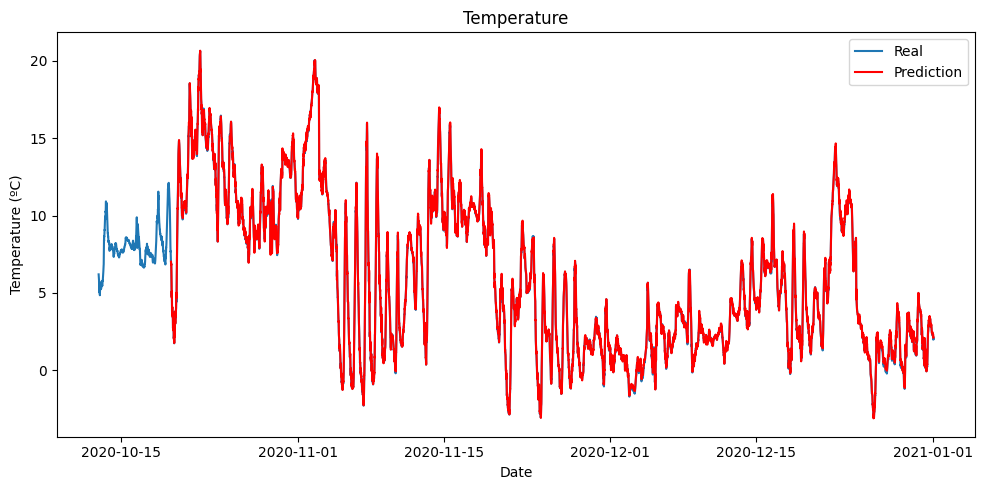

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.016244962811470032    │
│         test_rmse         │   0.019648121669888496    │
└───────────────────────────┴───────────────────────────┘

Test Results (Datos escalados):
	MAE: 0.0162
	RMSE: 0.0196

Test Results (Datos reales):
	MAE: 0.1254
	RMSE: 0.1516


In [ ]:
# Cargamos el mejor modelo
best_baseline_module = TemperaturePredictor.load_from_checkpoint(f'{BASE_PATH}/baseline/best_model_1e-3.ckpt', weights_only=False)

# Cargamos DataModule
data_module = TemperatureDataModule(df, batch_size=8, w=4)

# Preparamos Trainer
trainer = Trainer(deterministic=True, callbacks=[ForecastingCallback()])

# Probamos el mejor modelo cargado con el trainer y mostramos sus resultados en datos escalados
scaled_test_results = trainer.test(best_baseline_module, data_module)[0]
print('Test Results (Datos escalados):')
print(f'\tMAE: {scaled_test_results['test_loss']:.4f}')
print(f'\tRMSE: {scaled_test_results['test_rmse']:.4f}')

# Calculamos MAE y RMSE sobre datos sin escalar usando el mejor modelo
results_unscaled = inference(model=best_baseline_module.model, data_module=data_module, device=best_baseline_module.device)
print('\nTest Results (Datos reales):')
print(f'\tMAE: {results_unscaled['test_loss']:.4f}')
print(f'\tRMSE: {results_unscaled['test_rmse']:.4f}')

## 3. Propuestas

Existen distintas arquitecturas para el análisis y predicción de series temporales. En primera instancia, nos interesa evaluar arquitecturas con capas recurrentes como RNN, LSTM y GRU. Podemos comparar y evaluar dichas arquitecturas. Por otro lado, también es posible de realizar la predicción con un TransformerEncoder

Evaluaremos las arquitecturas mencionadas anteriormente:
*  Para las redes recurrentes nos puede interesar también ajustar: `hidden_size`, `num_layers`, `pooling` y `dropout`. Sin embargo, primero realizaremos un análisis comparativo con valores base: `hidden_size = 64`, `num_layers = 2`, `pooling = 'last'`, y sin `dropout`. Igualmente, todos tendrán una única capa lineal en la salida
*  Después se evaluará la opción con Transformers. En este caso, hay muchas más variables, pero usaremos hiperparametros sencillos por simplicidad que sean análogos a los escogidos para las RNNs
*  Finalmente, durante el análisis, podemos hacer experimentos extras sobre el mejor modelo (fine tuning)

Para todos los casos utilizaremos Adam como optimizador con un learning rate de 0.001, los datos tendrán un batch size de 64 y una ventana temporal igual a 6 (1h)

In [17]:
# Hiperparametros
batch_size = 64
w = 6
h = 1
lr = 1e-3
optimizer = torch.optim.Adam

data_module = TemperatureDataModule(df, batch_size=batch_size, w=w, h=h)
data_module.setup('fit')
input_size = data_module.train_dataset.features.shape[1]
chk_path = f'{BASE_PATH}/proposals'

### RNN

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/proposals exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaseRNNModel     │ 13.8 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 13.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

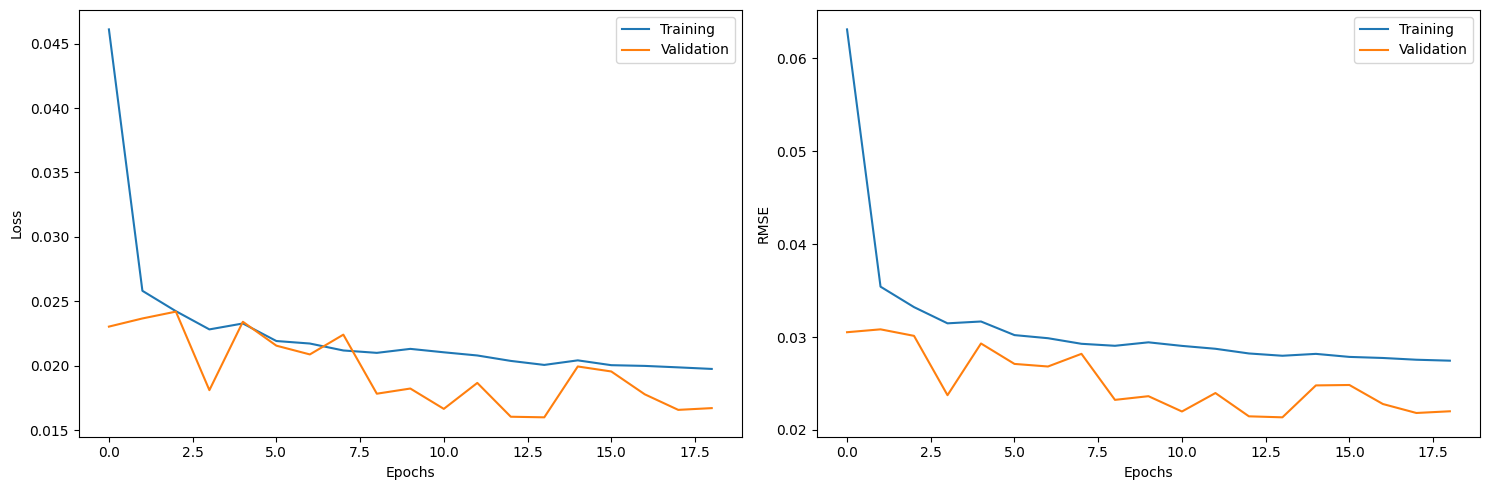

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.020412275567650795    │
│         test_rmse         │   0.024457933381199837    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.020412275567650795, 'test_rmse': 0.024457933381199837}]

In [ ]:
model = BaseRNNModel(input_size=input_size, h=h)
module = TemperaturePredictor(model, learning_rate=lr, optimizer=optimizer)

trainer = Trainer(
    deterministic=True,
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5),
        ModelCheckpoint(monitor='val_loss', filename=f'best_model_rnn', dirpath=chk_path, enable_version_counter=False),
        PlotCallback()
    ],
    max_epochs=50
)

trainer.fit(module, data_module)
trainer.test(module, data_module)

### LSTM

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/proposals exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaseRNNModel     │ 55.1 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 55.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 55.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

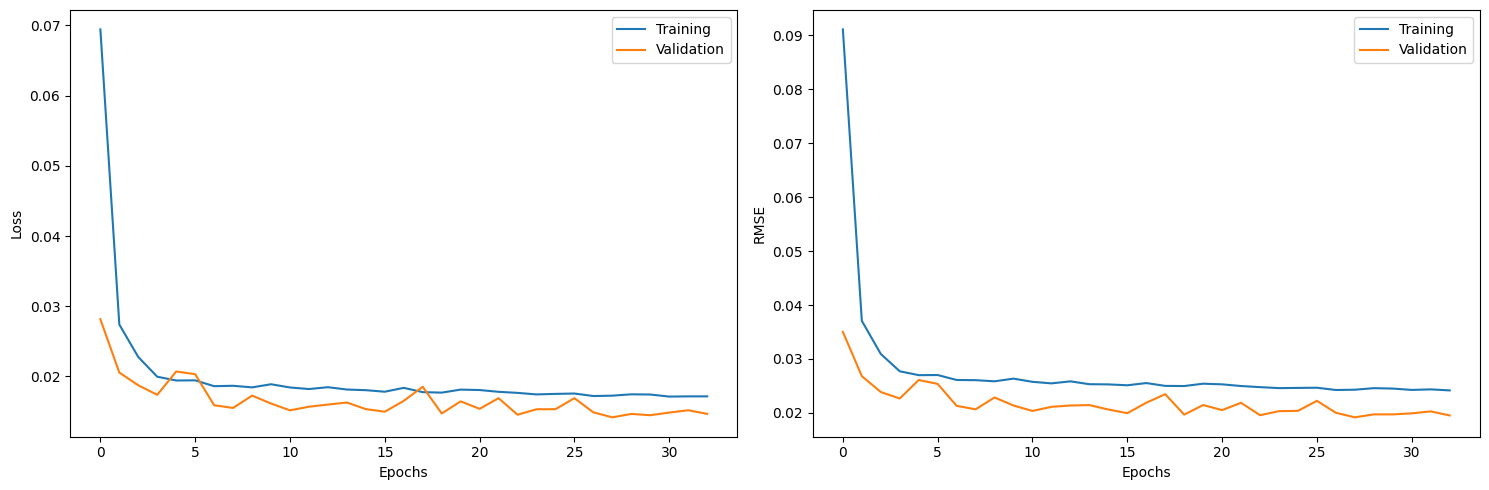

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.017352333292365074    │
│         test_rmse         │    0.02156060002744198    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.017352333292365074, 'test_rmse': 0.02156060002744198}]

In [ ]:
model = BaseRNNModel(input_size=input_size, h=h, model='lstm')
module = TemperaturePredictor(model, learning_rate=lr, optimizer=optimizer)

trainer = Trainer(
    deterministic=True,
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5),
        ModelCheckpoint(monitor='val_loss', filename=f'best_model_lstm', dirpath=chk_path, enable_version_counter=False),
        PlotCallback()
    ],
    max_epochs=50
)

trainer.fit(module, data_module)
trainer.test(module, data_module)

### GRU

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/proposals exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaseRNNModel     │ 41.3 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 41.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 41.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

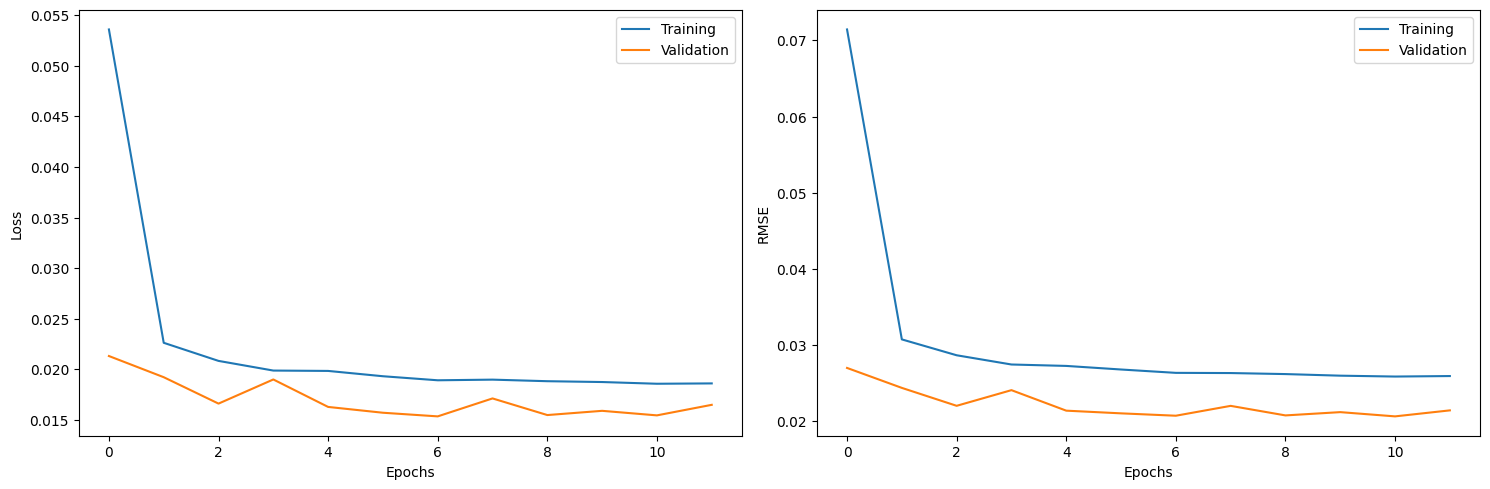

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.01447051391005516    │
│         test_rmse         │   0.018804917111992836    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.01447051391005516, 'test_rmse': 0.018804917111992836}]

In [ ]:
model = BaseRNNModel(input_size=input_size, h=h, model='gru')
module = TemperaturePredictor(model, learning_rate=lr, optimizer=optimizer)

trainer = Trainer(
    deterministic=True,
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5),
        ModelCheckpoint(monitor='val_loss', filename=f'best_model_gru', dirpath=chk_path, enable_version_counter=False),
        PlotCallback()
    ],
    max_epochs=50
)

trainer.fit(module, data_module)
trainer.test(module, data_module)

### Transformer

Debemos recordar que tanto la entrada como la salida del Transformer es `d_model`, por ende, debemos ajustar la dimensionalidad usando proyecciones en ambos casos. En el caso de la entrada es equivalente a realizar el embedding, por lo que tenemos que considerar el embedding posicional para mantener el orden

Por simplicidad usaremos Encoding Posicional aprendido, esto tiene mucho sentido ya que, a diferencia del texto, la relevancia entre la relación de los datos viene dada por su próximidad a los datos del pasado. En otras palabras, para predecir la temperatura es más relevante los datos del registro anterior que 6 registros atrás. Estamos más interesado en posiciones absolutas

In [22]:
class TemperatureTransformer(nn.Module):
    def __init__(self, input_size, w=4, d_model=64, nhead=4, num_layers=1, h=1, pooling='last', dim_feedforward=256, transf_type='encoder'):
        super().__init__()

        self.transf_type = transf_type

        LAYERS = { 'encoder': nn.TransformerEncoderLayer, 'decoder': nn.TransformerDecoderLayer }
        TRANSFORMERS = { 'encoder': nn.TransformerEncoder, 'decoder': nn.TransformerDecoder }

        self.input_proj = nn.Linear(input_size, d_model) # Proyección de las features a d_model
        self.pos_emb = nn.Embedding(w, d_model) # Encoding posicional
        self.layer = LAYERS.get(transf_type, nn.TransformerEncoderLayer)(d_model, nhead, dim_feedforward=dim_feedforward, batch_first=True) # Encoder Layer (análogo a RNNCell)
        self.transformer = TRANSFORMERS.get(transf_type, nn.TransformerEncoder)(self.layer, num_layers) # Transformer (análogo a RNN)
        self.linear = nn.Linear(d_model, h) # Proyección d_model a horizonte
        self.pooling = pooling

    def forward(self, x):
        batch_size, w, _ = x.shape # batch_size, w, n_features
        x = self.input_proj(x) # batch_size, w, d_model

        positions = torch.arange(w)
        x = x + self.pos_emb(positions) # batch_size, w, d_model

        if self.transf_type == 'decoder':
            x = self.transformer(tgt=x, memory=x, tgt_mask=torch.triu(torch.ones(w, w), diagonal=1).bool()) # batch_size, w, d_model
        else:
            x = self.transformer(x) # batch_size, w, d_model

        # Necesitamos pooling para reducir la dimensionalidad -> batch_size, d_model
        if self.pooling == 'last':
            x = x[:, -1, :]
        elif self.pooling == 'mean':
            x = torch.mean(x, dim=1)
        else:
            x = torch.amax(x, dim=1)
        x = self.linear(x) # batch_size, h
        return x

#### EncoderOnly

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/proposals exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ TemperatureTransformer │  101 K │ train │     0 │
│ 1 │ criterion │ L1Loss                 │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError       │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 101 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 101 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

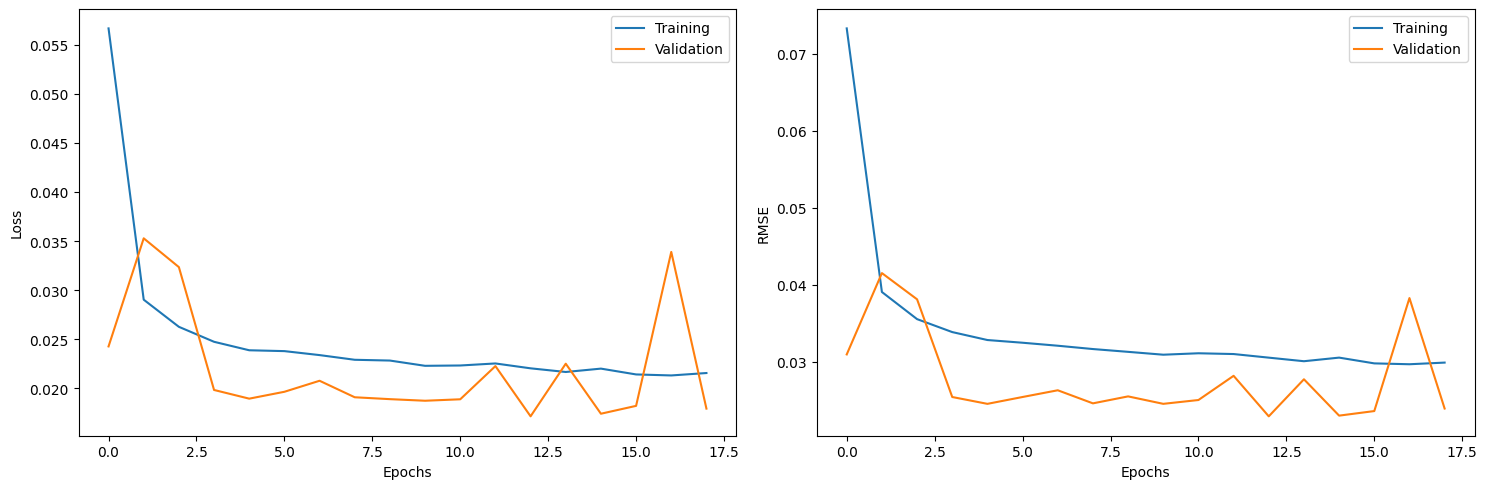

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.015272798016667366    │
│         test_rmse         │    0.0198644008487463     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.015272798016667366, 'test_rmse': 0.0198644008487463}]

In [23]:
model = TemperatureTransformer(input_size=input_size, w=w, h=h)
module = TemperaturePredictor(model)

trainer = Trainer(
    deterministic=True,
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5),
        ModelCheckpoint(monitor='val_loss', filename=f'best_model_transf_encoder', dirpath=chk_path, enable_version_counter=False),
        PlotCallback()
    ],
    max_epochs=50
)

trainer.fit(module, data_module)
trainer.test(module, data_module)

#### DecoderOnly

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/proposals exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ TemperatureTransformer │  135 K │ train │     0 │
│ 1 │ criterion │ L1Loss                 │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError       │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 135 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 135 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 36                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

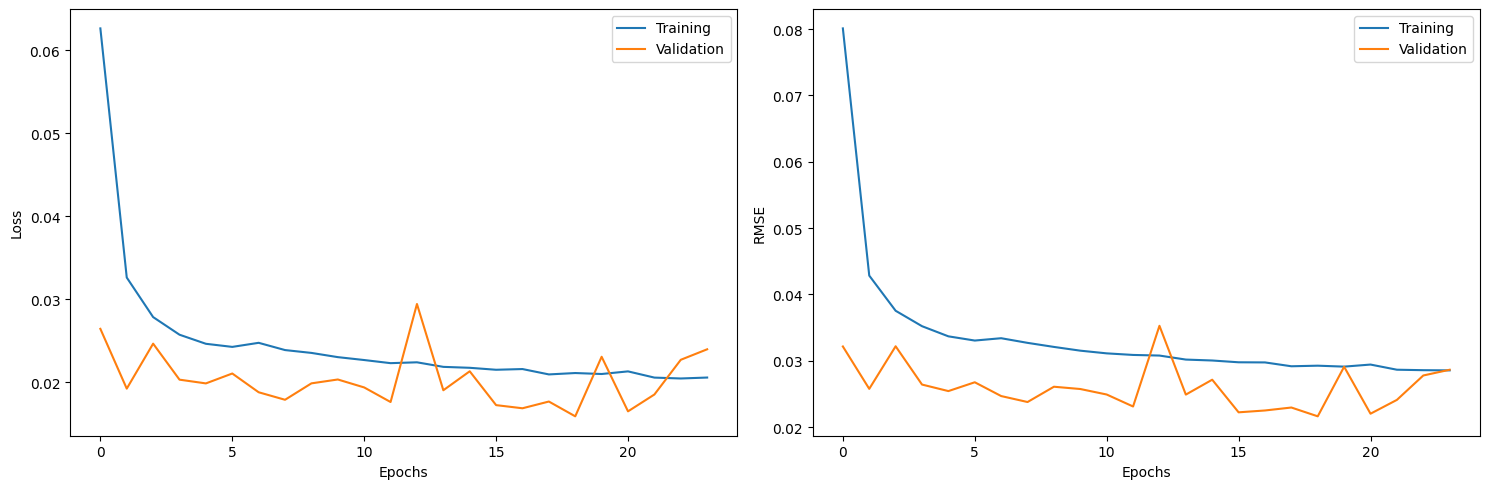

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.023390647023916245    │
│         test_rmse         │   0.027452746406197548    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.023390647023916245, 'test_rmse': 0.027452746406197548}]

In [24]:
model = TemperatureTransformer(input_size=input_size, w=w, h=h, transf_type='decoder')
module = TemperaturePredictor(model)

trainer = Trainer(
    deterministic=True,
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5),
        ModelCheckpoint(monitor='val_loss', filename=f'best_model_transf_decoder', dirpath=chk_path, enable_version_counter=False),
        PlotCallback()
    ],
    max_epochs=50
)

trainer.fit(module, data_module)
trainer.test(module, data_module)

## 4. Tabla de resultados

Para poder comparar los resultados lo mejor posible, vamos a considerar el mejor modelo para cada arquitectura:

In [27]:
# Preparamos datos base
proposal_data_module = TemperatureDataModule(df, batch_size=64, w=6, h=1)
best_modules = []

best_modules.append(
    {
        'Name': 'baseline',
        'Batch Size': 8,
        'Window': 4
    }
)

for proposal in ['rnn', 'lstm', 'gru', 'transf_encoder', 'transf_decoder']:
    best_modules.append(
        {
            'Name': proposal,
            'Batch Size': 64,
            'Window': 6
        }
    )

# Iteramos sobre cada module y completamos la información
for module_dict in best_modules:
    if module_dict['Name'] == 'baseline':
        module = TemperaturePredictor.load_from_checkpoint(f'{BASE_PATH}/baseline/best_model_1e-3.ckpt', weights_only=False)
        data_module = TemperatureDataModule(df, batch_size=module_dict['Batch Size'], w=module_dict['Window'], h=1)
    else:
        module = TemperaturePredictor.load_from_checkpoint(f'{BASE_PATH}/proposals/best_model_{module_dict['Name']}.ckpt', weights_only=False)
        data_module = proposal_data_module

    module_dict['LR'] = module.learning_rate
    module_dict['Optimizer'] = module.optimizer.__name__
    module_dict['Total Params'] = sum(p.numel() for p in module.model.parameters())

    # Resultados escalados
    trainer = Trainer(deterministic=True)
    scaled_test_results = trainer.test(module, data_module, verbose=False)[0]
    module_dict['Scaled Loss'] = scaled_test_results['test_loss']
    module_dict['Scaled RMSE'] = scaled_test_results['test_rmse']

    # Resultados reales
    real_test_results = inference(model=module.model, data_module=data_module, device=module.device)
    module_dict['Real Loss'] = real_test_results['test_loss']
    module_dict['Real RMSE'] = real_test_results['test_rmse']

results_df = pd.DataFrame(best_modules)
results_df.sort_values('Real Loss', inplace=True)
results_df.set_index('Name', inplace=True)
results_df

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

,Batch Size,Window,LR,Optimizer,Total Params,Scaled Loss,Scaled RMSE,Real Loss,Real RMSE
Name,,,,,,,,,
lstm,64,6,0.001,Adam,55105,0.013210,0.017615,0.101863,0.135820
transf_decoder,64,6,0.001,Adam,135233,0.013747,0.018341,0.105952,0.141346
gru,64,6,0.001,Adam,41345,0.013872,0.018264,0.106948,0.140807
rnn,64,6,0.001,Adam,13825,0.013902,0.018181,0.107157,0.140138
transf_encoder,64,6,0.001,Adam,101697,0.014964,0.019697,0.115323,0.151799
baseline,8,4,0.001,SGD,7801,0.016245,0.019648,0.125371,0.151618


Cualquiera de las arquitecturas RNN tienen un excelente desempeño obtienen resultados muy similares. Por otro lado, todas las propuestas superaron el mejor baseline

## 5. Análisis

Todos los modelos superaron el baseline, el cual refleja excelentes resultados también (MAE `0.1254`)

Como se pensó inicialmente, las RNNs son ideales para este tipo de análisis. Sin embargo, si analizamos cada modelo en detalle:
*  LSTM: El mejor modelo en estudio. Obtiene los mejores resultados con un MAE real de `0.1018`. Aún así es el modelo que tardó más en converger
*  GRU: Mucho más rápido que el resto y resultados sobresaliente. Es un poco más ligero que LSTM y obtuvo un MAE real de `0.1069`
*  RNN: Es el "peor" modelo de los RNNs, sin embargo, obtiene resultados similares al mejor (LSTM) con un MAE sobre datos sin escalado igual a `0.1071` (casi idéntico a GRU). Por otro lado, es el modelo más sencillo de todos (exceptuando el baseline) teniendo solo ~25% de los parámetros del LSTM
*  TransformerEncoder: no está muy detrás de las RNNs con MAE `0.1185`. Sin embargo, es con creces el modelo más complejo. Adicionalmente, su complejidad no está a la par de la dificultad de la tarea.
*  TransformerDecoder: aunque el EncoderOnly puede ser la recomendación inicial para problemas de predicción ya que deseamos obtener el siguiente valor (horizonte) en base a los datos existentes, los resultados señalan que el DecoderOnly es muy superior. Esto se debe a la causalidad de nuestro problema. Mientras que el Encoder realiza un análisis bidireccional para entender y predecir el valor futuro, el Decoder solo se enfoca en los valores del pasado, es decir, es causal. Esta pequeña diferencia puede reducir el ruido del aprendizaje y actuar de forma similar a los modelos RNN. Esta metodología nos permitió obtener el segundo mejor resultado: `0.1059`. Aún así, es un modelo sumamente complejo para la tarea con más de 135K parámetros

Directamente podemos descartar los Transformers y GRU de las propuestas:
*  Transformers son demasiado complejos para la tarea
*  GRU no aporta mejora significativa en cantidad de parámetros versus LSTM y tampoco obtiene resultados mucho mejores que RNN

La decisión final dependerá de la precisión que se desea para el modelo final. LSTM es más preciso y puede tener más puntos de mejora al tardar más en converger, es decir, se puede realizar fine-tuning para ajustarse a los datos aún más. Si la precisión no es un factor crítico, RNN es la mejor opción, varía en 0.0053ºC frente a LSTM, pero es mucho más rápida y menos compleja

Para continuar con el análisis de otros críterios y realizar fine-tuning, utilizaremos LSTM para tener mayor margen de mejora

### 5.1 Impacto de Feature Selection

Como pudimos observar en el análisis del dataset, hay una alta correlación entre múltiples features. Se ha preparado distintas alternativas para simplificar y mejorar el modelo final: PCA y Feature Selection

Vamos a realizar una comparación entre los resultados para cada caso:

In [ ]:
# Fijamos variables
batch_size = 64
w = 6
h = 1
chk_path = f'{BASE_PATH}/feature_selection'

# Lista de diccionarios para cada data module
data_modules = [
    { 'Name': 'simple', 'data_module': TemperatureDataModule(df, batch_size=batch_size, w=w) },
    { 'Name': 'pca', 'data_module': TemperatureDataModule(df, batch_size=batch_size, w=w, reduction_strategy='pca') },
    { 'Name': 'selection', 'data_module': TemperatureDataModule(df, batch_size=batch_size, w=w, reduction_strategy='selection') }
]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/feature_selection exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaseRNNModel     │ 55.1 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 55.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 55.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

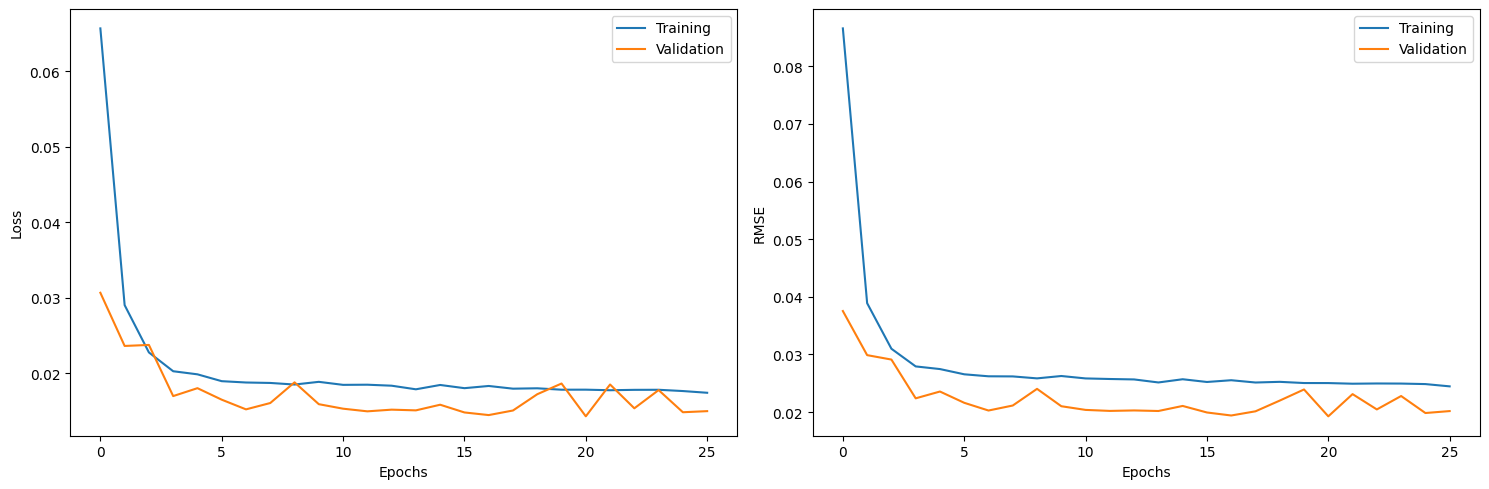

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/feature_selection exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaseRNNModel     │ 53.3 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 53.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 53.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

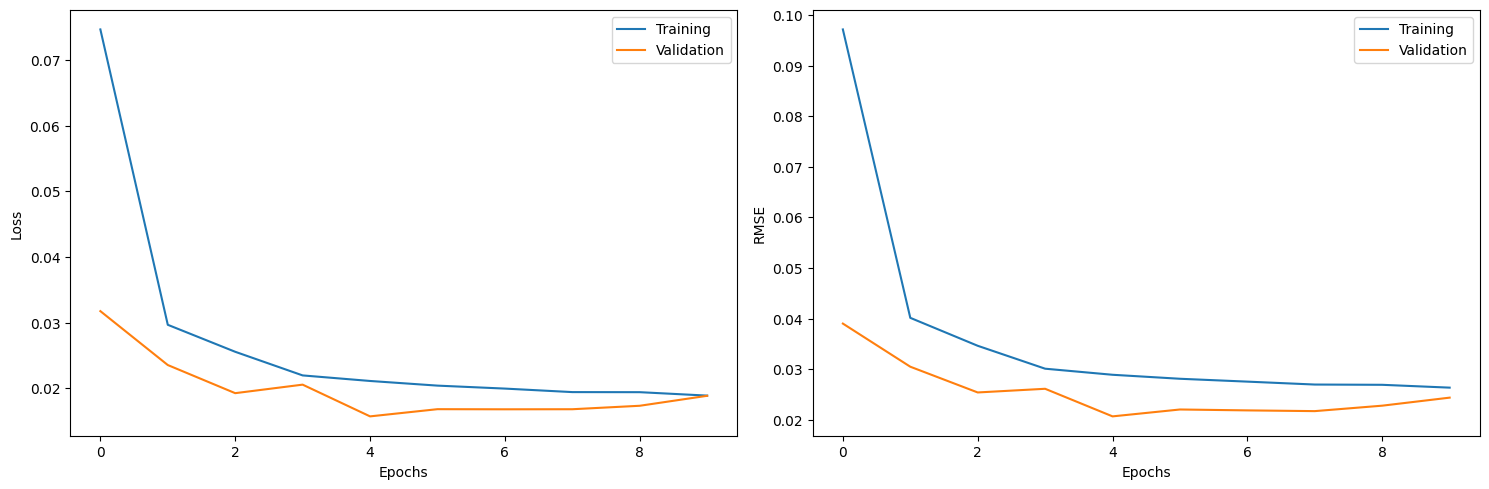

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/feature_selection exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaseRNNModel     │ 53.3 K │ train │     0 │
│ 1 │ criterion │ L1Loss           │      0 │ train │     0 │
│ 2 │ rmse      │ MeanSquaredError │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 53.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 53.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

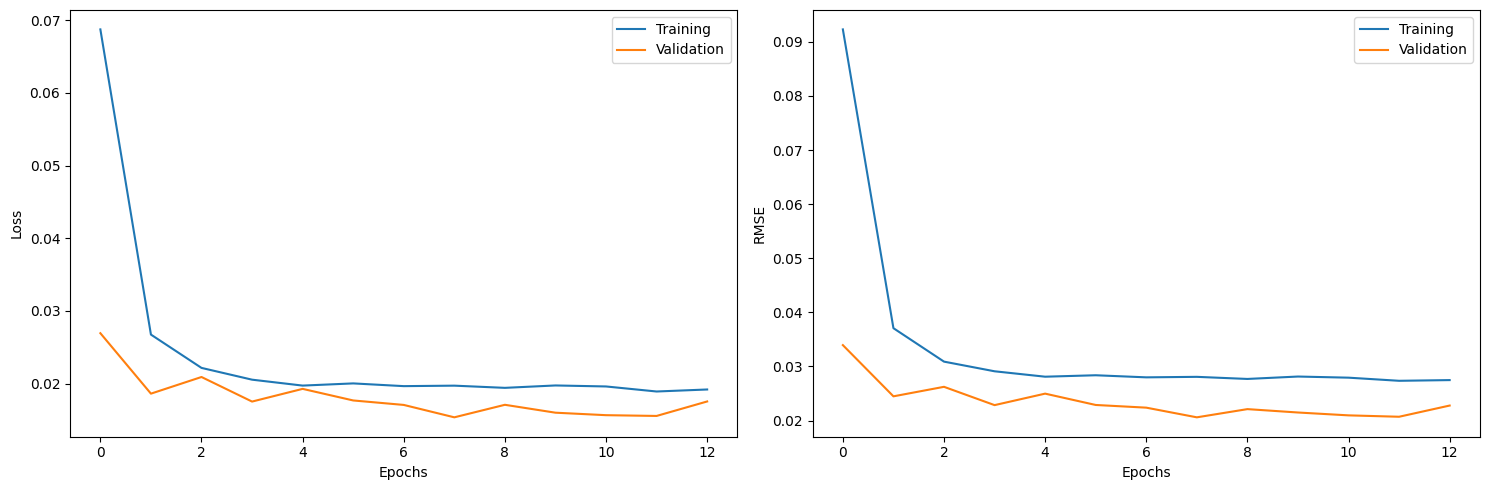

In [ ]:
# Iteramos sobre la lista
for data_module_dict in data_modules:
    # Cargamos el data_module
    data_module = data_module_dict['data_module']
    name = data_module_dict['Name']

    # Preparamos el mejor modelo hasta el momento
    data_module.setup('fit')
    model = BaseRNNModel(input_size=data_module.train_dataset.features.shape[1], h=h, model='lstm')
    module = TemperaturePredictor(model)

    # Trainer
    trainer = Trainer(
        deterministic=True,
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=5),
            ModelCheckpoint(monitor='val_loss', filename=f'best_model_{name}', dirpath=chk_path, enable_version_counter=False),
            PlotCallback()
        ],
        max_epochs=50
    )

    trainer.fit(module, data_module)

In [ ]:
# Preparamos resultados
for data_module_dict in data_modules:
    # Cargamos data_module
    data_module = data_module_dict['data_module']
    name = data_module_dict['Name']

    # Cargamos mejor module
    module = TemperaturePredictor.load_from_checkpoint(f'{BASE_PATH}/feature_selection/best_model_{name}.ckpt', weights_only=False)
    trainer = Trainer(deterministic=True)

    # Resultados escalados
    scaled_test_results = trainer.test(module, data_module, verbose=False)[0]
    data_module_dict['Scaled Loss'] = scaled_test_results['test_loss']
    data_module_dict['Scaled RMSE'] = scaled_test_results['test_rmse']

    # Resultados sin esclar
    real_test_results = inference(model=module.model, data_module=data_module, device=module.device)
    data_module_dict['Real Loss'] = real_test_results['test_loss']
    data_module_dict['Real RMSE'] = real_test_results['test_rmse']

# Creamos una tabla
results_df = pd.DataFrame(data_modules)
results_df.drop('data_module', axis=1, inplace=True)
results_df.sort_values('Real Loss', inplace=True)
results_df.set_index('Name', inplace=True)
results_df

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Output()

,Scaled Loss,Scaled RMSE,Real Loss,Real RMSE
Name,,,,
simple,0.013333,0.017715,0.102770,0.136540
pca,0.014101,0.018521,0.108679,0.142747
selection,0.014118,0.018575,0.108822,0.143168


Los resultados no son muy diferentes, esto implica que aunque haya mucha correlación entre las features, el modelo se adapta muy bien a ella. Sin embargo, el uso de PCA o Feature Selection simplifica el entrenamiento y tamaño del modelo. Podemos seguir usando Feature Selection. Aunque obtuvo los peores resultados, simplifica el entrenamiento como PCA obteniendo resultados similares y permite explicar la relevancia de cada feature

### 5.2 Fine Tuning

Finalmente, se interará mejorar el modelo ajustando los hiperparametros. En concreto, se modificará:
*  Window: [6 (1h), 72 (12h), 144 (24h)]
*  Num Layer: [1, 2, 3]
*  Hidden Size: [64, 128, 256]
*  Dropout: [0..0.4]
*  Learning Rate: [1e-4..1e-3]
*  Batch Size: [64, 128]

Es un espacio de búsqueda bastante amplio. Para simplificar el trabajo, usaremos Ray Tune que se integra perfectamente con Pytorch Lightning. En este caso usaremos la configuración por default (RandomSearch) en conjunto con un scheduler para detener pruebas malas. Adicionalmente, RayTune nos permite realizar el fine-tuning paralelizando los trials. Limitaremos el número de trials a 100

Como criterio usaremos directamente el `val_loss` (MAE escalado) del Trainer ya que tiene una relación lineal con el MAE real (MAE real = MAE escalado * target std)

In [ ]:
# Preparamos el tuning
chk_path = f'{BASE_PATH}/fine_tuning'

def train_tune(config):
    # Cargamos data module
    data_module = TemperatureDataModule(
        df,
        w=config['window'],
        batch_size=config['batch_size'],
        reduction_strategy='selection'
    )
    data_module.setup('fit')

    # Preparamos modelo
    model = BaseRNNModel(
        input_size=data_module.train_dataset.features.shape[1],
        model='lstm',
        hidden_size=config['hidden_size'],
        num_layers=config['num_layers'],
        dropout=config['dropout']
    )

    # Module
    module = TemperaturePredictor(model, learning_rate=config['lr'])

    # Trainer
    trainer = Trainer(
        max_epochs=50,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=2),
            TuneReportCheckpointCallback(metrics={ 'val_loss': 'val_loss' }),
        ],
        deterministic=True,
        enable_model_summary=False,
        enable_progress_bar=False
    )

    trainer.fit(module, data_module)

# Hiperparametros a probar
search_space = {
    'hidden_size': tune.choice([64, 128, 256]),
    'num_layers': tune.choice([1, 2, 3]),
    'dropout': tune.uniform(0.0, 0.4),
    'lr': tune.loguniform(1e-4, 1e-3),
    'batch_size': tune.choice([64, 128]),
    'window': tune.choice([6, 72, 144])
}

In [ ]:
analysis = tune.run(
    train_tune,
    config=search_space,
    num_samples=100,
    scheduler=ASHAScheduler(metric='val_loss', mode='min'), # Detiene los trials malos
    resources_per_trial={
        "cpu": 2,
        "gpu": 1 if torch.cuda.is_available() else 0
    },
    storage_path=chk_path,
)

2025-12-26 10:04:10,333	INFO worker.py:1998 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2025-12-26 10:04:20,694	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.


+-------------------------------------------------------------------+
| Configuration for experiment     train_tune_2025-12-26_10-04-20   |
+-------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator            |
| Scheduler                        AsyncHyperBandScheduler          |
| Number of trials                 100                              |
+-------------------------------------------------------------------+

View detailed results here: /content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/fine_tuning/train_tune_2025-12-26_10-04-20
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2025-12-26_10-03-46_849991_374/artifacts/2025-12-26_10-04-23/train_tune_2025-12-26_10-04-20/driver_artifacts`
(raylet) Warning: The actor ImplicitFunc is very large (17 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to p

(train_tune pid=1963) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
(train_tune pid=1963) 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
(train_tune pid=1963) GPU available: True (cuda), used: True
(train_tune pid=1963) TPU available: False, using: 0 TPU cores
(train_tune pid=1963) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:45: Attribute 'model' removed from hparams because it cannot be pickled. You can suppress this warning by setting `self.save_hyperparameters(ignore=['model'])`.
(train_tune pid=1963) 2025-12-26 10:04:54.638616: E external/local_xla/xla/stream_executor/cuda/cuda_fft


Trial status: 1 RUNNING | 99 PENDING
Current time: 2025-12-26 10:05:06. Total running time: 39s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
+----------------------------------------------------------------------------------------------------------------------+
| Trial name               status       hidden_size     num_layers     dropout            lr     batch_size     window |
+----------------------------------------------------------------------------------------------------------------------+
| train_tune_410cc_00000   RUNNING              128              2   0.160587    0.000920032            128        144 |
| train_tune_410cc_00001   PENDING               64              2   0.0577925   0.000118593             64          6 |
| train_tune_410cc_00002   PENDING              256              3   0.0369708   0.000947987            128        144 |
| train_tune_410cc_00003   PENDING               64              3   0.183455    0.000133216        

(train_tune pid=1963) `weights_only` was not set, defaulting to `False`.
(train_tune pid=1963) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/fine_tuning/train_tune_2025-12-26_10-04-20/train_tune_410cc_00000_0_batch_size=128,dropout=0.1606,hidden_size=128,lr=0.0009,num_layers=2,window=144_2025-12-26_10-04-31/checkpoint_000000)


...


Trial train_tune_410cc_00099 started with configuration:
+-------------------------------------------------+
| Trial train_tune_410cc_00099 config             |
+-------------------------------------------------+
| batch_size                                  128 |
| dropout                                 0.31283 |
| hidden_size                                 128 |
| lr                                       0.0004 |
| num_layers                                    3 |
| window                                      144 |
+-------------------------------------------------+

Trial status: 99 TERMINATED | 1 RUNNING
Current time: 2025-12-26 11:14:44. Total running time: 1hr 10min 17s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name               status         hidden_size     num_layers   

(train_tune pid=31511) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
(train_tune pid=31511) 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
(train_tune pid=31511) GPU available: True (cuda), used: True
(train_tune pid=31511) TPU available: False, using: 0 TPU cores
(train_tune pid=31511) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:45: Attribute 'model' removed from hparams because it cannot be pickled. You can suppress this warning by setting `self.save_hyperparameters(ignore=['model'])`.
(train_tune pid=31511) 2025-12-26 11:14:47.151545: E external/local_xla/xla/stream_executor/cuda/cu


Trial train_tune_410cc_00099 finished iteration 1 at 2025-12-26 11:15:06. Total running time: 1hr 10min 39s
+-----------------------------------------------------------+
| Trial train_tune_410cc_00099 result                       |
+-----------------------------------------------------------+
| checkpoint_dir_name                     checkpoint_000000 |
| time_this_iter_s                                 25.68649 |
| time_total_s                                     25.68649 |
| training_iteration                                      1 |
| val_loss                                           0.0405 |
+-----------------------------------------------------------+
Trial train_tune_410cc_00099 saved a checkpoint for iteration 1 at: (local)/content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/fine_tuning/train_tune_2025-12-26_10-04-20/train_tune_410cc_00099_99_batch_size=128,dropout=0.3128,hidden_size=128,lr=0.0004,num_layers=3,window=144_2025-12-26_10-04-35/checkpoint_000000

Trial train_

(train_tune pid=31511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/fine_tuning/train_tune_2025-12-26_10-04-20/train_tune_410cc_00099_99_batch_size=128,dropout=0.3128,hidden_size=128,lr=0.0004,num_layers=3,window=144_2025-12-26_10-04-35/checkpoint_000000)
2025-12-26 11:15:10,018	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/fine_tuning/train_tune_2025-12-26_10-04-20' in 3.9785s.



Trial status: 100 TERMINATED
Current time: 2025-12-26 11:15:10. Total running time: 1hr 10min 43s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
+------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name               status         hidden_size     num_layers      dropout            lr     batch_size     window     iter     total time (s)     val_loss |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| train_tune_410cc_00000   TERMINATED             128              2   0.160587     0.000920032            128        144        7            48.3646    0.0265557 |
| train_tune_410cc_00001   TERMINATED              64              2   0.0577925    0.000118593             64          6        1            15.4344    0.0489754 |

In [ ]:
# Extraemos los datos más relevantes
analysis_df = analysis.dataframe(metric='val_loss', mode='min')
analysis_df.sort_values('val_loss', inplace=True)
columns_to_show = analysis_df.columns[analysis_df.columns.str.startswith('config')].to_list() + ['trial_id', 'val_loss']
display(analysis_df[columns_to_show].head(10)) # Mejores 10 trials


best_trial = analysis.get_best_trial(metric='val_loss', mode='min')
best_config = analysis.get_best_config(metric='val_loss', mode='min')
best_checkpoint = analysis.get_best_checkpoint(metric='val_loss', mode='min', trial=best_trial)
print(f'Mejor trial: {best_trial}')
print(f'Mejor configuración: {best_config}')
print(f'Mejor checkpoint: {best_checkpoint}')

,config/hidden_size,config/num_layers,config/dropout,config/lr,config/batch_size,config/window,trial_id,val_loss
5,256,1,0.276722,0.000487,128,72,410cc_00005,0.014729
39,256,1,0.241092,0.000769,64,6,410cc_00039,0.014790
69,64,1,0.339099,0.000796,64,6,410cc_00069,0.014830
68,64,1,0.180981,0.000842,128,144,410cc_00068,0.015060
9,64,1,0.327110,0.000883,128,72,410cc_00009,0.015208
2,256,3,0.036971,0.000948,128,144,410cc_00002,0.015604
93,256,1,0.174859,0.000544,128,72,410cc_00093,0.016457
76,256,1,0.149759,0.000326,64,6,410cc_00076,0.016781
7,64,1,0.221642,0.000837,128,6,410cc_00007,0.017174
26,128,1,0.109947,0.000576,64,72,410cc_00026,0.017378


Mejor trial: train_tune_410cc_00005
Mejor configuración: {'hidden_size': 256, 'num_layers': 1, 'dropout': 0.27672218127428627, 'lr': 0.0004865138391933615, 'batch_size': 128, 'window': 72}
Mejor checkpoint: Checkpoint(filesystem=local, path=/content/drive/MyDrive/Personal/UPM/Deep Learning/Entrega/fine_tuning/train_tune_2025-12-26_10-04-20/train_tune_410cc_00005_5_batch_size=128,dropout=0.2767,hidden_size=256,lr=0.0005,num_layers=1,window=72_2025-12-26_10-04-32/checkpoint_000008)


Ray Tune nos indica que la mejor configuración encontrada con un `val_loss = 0.014729` fue:
*  Hidden Size: 256
*  Num Layers: 1
*  Dropout: 0.27672218127428627
*  Learning rate: 0.0004865138391933615
*  Batch Size: 128
*  Window: 72



## 6. Inferencia

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.27672218127428627 and num_layers=1
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


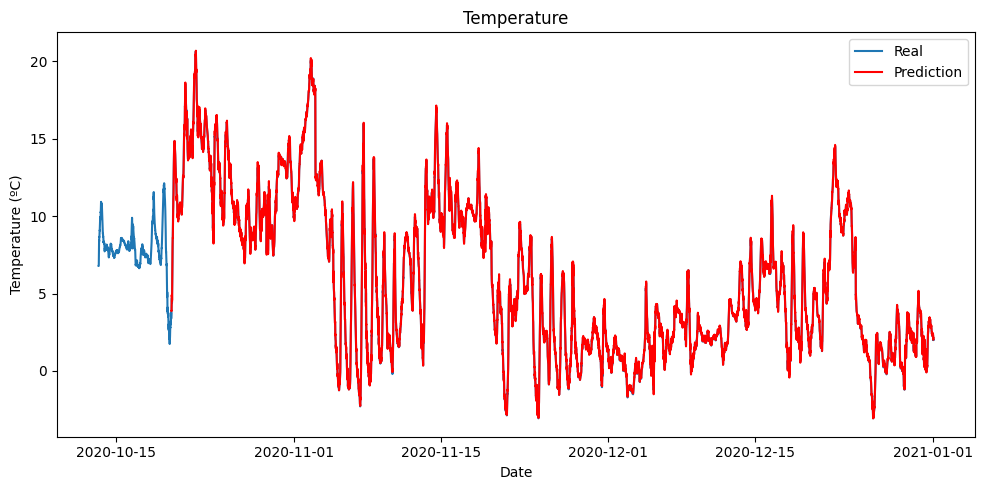

Test Results:
	Loss: 0.09574794505790966
	RMSE: 0.13471757034521278


In [ ]:
try:
    path = best_checkpoint.path + '/checkpoint'
except NameError:
    path = f'{BASE_PATH}/fine_tuning/train_tune_2025-12-26_10-04-20/train_tune_410cc_00005_5_batch_size=128,dropout=0.2767,hidden_size=256,lr=0.0005,num_layers=1,window=72_2025-12-26_10-04-32/checkpoint_000008/checkpoint'
    best_config = {
        'batch_size': 128,
        'dropout': 0.27672218127428627,
        'hidden_size': 256,
        'lr': 0.0004865138391933615,
        'num_layers': 1,
        'window': 72
    }

# Data Module
batch_size = best_config['batch_size']
window = best_config['window']

data_module = TemperatureDataModule(df, batch_size=batch_size, w=window, h=1, reduction_strategy='selection')
data_module.setup('fit')

# Model
model = BaseRNNModel(
    input_size=data_module.train_dataset.features.shape[1],
    h=1,
    model='lstm',
    hidden_size=best_config['hidden_size'],
    num_layers=best_config['num_layers'],
    dropout=best_config['dropout']
)

# Module
module = TemperaturePredictor.load_from_checkpoint(
    checkpoint_path=path,
    model=model,
    learning_rate=best_config['lr'],
    weights_only=False
)

# Inferencia
results = inference(model=module.model, data_module=data_module, device=module.device, forescasting=True)

print('Test Results:')
print('\tLoss:', results['test_loss'])
print('\tRMSE:', results['test_rmse'])